# Liverpool Energy Performance Certificate Analysis
## COM6003 Data Science — Buckinghamshire New University 2025-26

**Dataset:** Energy Performance of Buildings — Liverpool (Local Authority: E08000012)  
**Source:** Ministry of Housing, Communities and Local Government (MHCLG) Open Data Portal  

This notebook presents a complete end-to-end data science pipeline: data acquisition, feature engineering, data wrangling, descriptive analytics, diagnostic analytics, predictive modelling (classification, regression), clustering, and a recommendation system.

## Section 1: Data Acquisition and Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               RandomForestRegressor, GradientBoostingRegressor)
from sklearn.metrics import (accuracy_score, f1_score, confusion_matrix,
                              classification_report,
                              mean_absolute_error, mean_squared_error, r2_score)
from sklearn.inspection import permutation_importance
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.family']      = 'DejaVu Sans'
plt.rcParams['axes.titlesize']   = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize']   = 11
plt.rcParams['xtick.labelsize']  = 10
plt.rcParams['ytick.labelsize']  = 10
sns.set_theme(style='whitegrid', palette='muted')

RATING_COLORS = {'A':'#2ecc71','B':'#27ae60','C':'#f1c40f','D':'#e67e22','E':'#e74c3c'}
AGE_COLORS    = ['#8e44ad','#2980b9','#27ae60','#f39c12','#e67e22','#e74c3c','#1abc9c']
PALETTE       = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6']
EFF_COLORS    = ['#2ecc71','#27ae60','#f1c40f','#e67e22','#e74c3c']
CLUSTER_COLORS= ['#3498db','#e74c3c','#2ecc71','#f39c12']
AGE_ORDER     = ['Pre-1900','1900-1949','1950-1975','1976-1990','1991-2002','2003-2021','Post-2021']
EFF_ORDER     = ['Very Good','Good','Average','Poor','Very Poor']

def bar_labels(ax, bars, values, total=None, fmt=',.0f', offset_pct=0.015, fontsize=9.5):
    span = ax.get_ylim()[1] - ax.get_ylim()[0]
    for bar, val in zip(bars, values):
        label = f'{val:{fmt}}'
        if total:
            label += f'\n({val/total*100:.1f}%)'
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+span*offset_pct,
                label, ha='center', va='bottom', fontsize=fontsize, fontweight='bold')

df   = pd.read_csv('certificates.csv', low_memory=False)
recs = pd.read_csv('recommendations.csv', low_memory=False)

print(f'Certificates   : {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'Recommendations: {recs.shape[0]:,} rows, {recs.shape[1]} columns')
print(f'Local authority: {df["LOCAL_AUTHORITY_LABEL"].unique()}')
print(f'Date range     : {df["INSPECTION_DATE"].min()}  to  {df["INSPECTION_DATE"].max()}')

Certificates   : 5,000 rows, 93 columns
Recommendations: 10,297 rows, 7 columns
Local authority: <ArrowStringArray>
['Liverpool']
Length: 1, dtype: str
Date range     : 2024-11-24  to  2026-02-28


### 1.1 Dataset Overview

In [2]:
print('Shape:', df.shape)
print()
print('Column data types:')
print(df.dtypes.value_counts())
print()
preview_cols = ['CURRENT_ENERGY_RATING','CURRENT_ENERGY_EFFICIENCY','PROPERTY_TYPE',
                'CONSTRUCTION_AGE_BAND','TENURE','TOTAL_FLOOR_AREA',
                'CO2_EMISSIONS_CURRENT','HEATING_COST_CURRENT']
display(df[preview_cols].head(3))

Shape: (5000, 93)

Column data types:
str        53
float64    21
int64      19
Name: count, dtype: int64



,CURRENT_ENERGY_RATING,CURRENT_ENERGY_EFFICIENCY,PROPERTY_TYPE,CONSTRUCTION_AGE_BAND,TENURE,TOTAL_FLOOR_AREA,CO2_EMISSIONS_CURRENT,HEATING_COST_CURRENT
0,C,71,Flat,England and Wales: 1950-1966,Rented (social),42.0,1.3,423
1,C,75,Flat,England and Wales: 1983-1990,Rented (private),30.0,1.1,195
2,C,75,Flat,England and Wales: 1983-1990,Rented (private),29.0,1.1,188


### 1.2 Missing Values Analysis

Columns with missing values: 33 of 93


,Missing Count,Missing %
COUNTY,5000,100.00%
LOW_ENERGY_FIXED_LIGHT_COUNT,5000,100.00%
MAIN_HEATING_CONTROLS,5000,100.00%
GLAZED_AREA,5000,100.00%
GLAZED_TYPE,5000,100.00%
SHEATING_ENV_EFF,5000,100.00%
CONSTITUENCY_LABEL,5000,100.00%
SHEATING_ENERGY_EFF,5000,100.00%
FLOOR_ENV_EFF,4936,98.72%
FLOOR_ENERGY_EFF,4936,98.72%


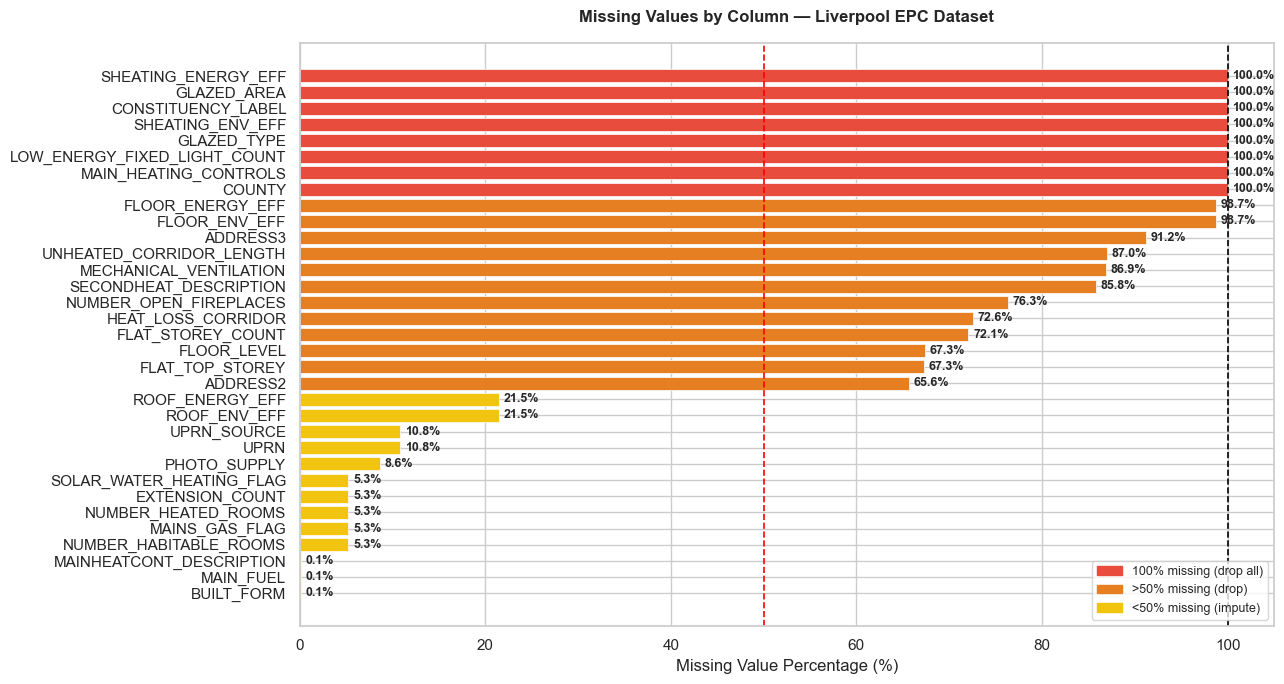

In [3]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df  = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(f'Columns with missing values: {len(missing_df)} of {df.shape[1]}')
display(missing_df.style.background_gradient(subset=['Missing %'], cmap='Reds').format({'Missing %': '{:.2f}%'}))

fig, ax = plt.subplots(figsize=(13, 7))
missing_plot  = missing_df[missing_df['Missing %'] > 0].sort_values('Missing %')
colors_miss   = ['#e74c3c' if v == 100 else '#e67e22' if v > 50 else '#f1c40f'
                 for v in missing_plot['Missing %']]
bars = ax.barh(missing_plot.index, missing_plot['Missing %'],
               color=colors_miss, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, missing_plot['Missing %']):
    ax.text(val+0.5, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
ax.axvline(50,  color='red',   linestyle='--', linewidth=1.2, label='50% threshold')
ax.axvline(100, color='black', linestyle='--', linewidth=1.2, label='100% missing')
legend_patches = [
    mpatches.Patch(color='#e74c3c', label='100% missing (drop all)'),
    mpatches.Patch(color='#e67e22', label='>50% missing (drop)'),
    mpatches.Patch(color='#f1c40f', label='<50% missing (impute)'),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)
ax.set_xlabel('Missing Value Percentage (%)')
ax.set_title('Missing Values by Column — Liverpool EPC Dataset', pad=15)
plt.tight_layout()
plt.savefig('chart0_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.3 Duplicate Records

In [4]:
total_dups = df.duplicated().sum()
lmk_dups   = df.duplicated(subset=['LMK_KEY']).sum()
print(f'Fully duplicate rows    : {total_dups}')
print(f'Duplicate LMK_KEY values: {lmk_dups}')
if total_dups > 0:
    df = df.drop_duplicates()
    print(f'Removed {total_dups} rows. Remaining: {len(df):,}')
else:
    print('No duplicate rows found. Each certificate is unique.')

Fully duplicate rows    : 0
Duplicate LMK_KEY values: 0
No duplicate rows found. Each certificate is unique.


### 1.4 Target Variable and Key Statistics

In [5]:
rating_counts  = df['CURRENT_ENERGY_RATING'].value_counts().sort_index()
rating_pct     = (rating_counts / len(df) * 100).round(1)
rating_summary = pd.DataFrame({'Count': rating_counts, 'Percentage (%)': rating_pct})
rating_summary['Cumulative %'] = rating_pct.cumsum().round(1)
print('Target variable: CURRENT_ENERGY_RATING')
display(rating_summary)
print()
key_cols = ['CURRENT_ENERGY_EFFICIENCY','POTENTIAL_ENERGY_EFFICIENCY',
            'TOTAL_FLOOR_AREA','CO2_EMISSIONS_CURRENT',
            'ENERGY_CONSUMPTION_CURRENT','HEATING_COST_CURRENT',
            'HOT_WATER_COST_CURRENT','LIGHTING_COST_CURRENT']
display(df[key_cols].describe().round(2)
        .style.background_gradient(cmap='Blues', subset=pd.IndexSlice['mean':'max', :]))

Target variable: CURRENT_ENERGY_RATING


,Count,Percentage (%),Cumulative %
CURRENT_ENERGY_RATING,,,
A,70,1.4,1.4
B,457,9.1,10.5
C,3251,65.0,75.5
D,1083,21.7,97.2
E,102,2.0,99.2
F,25,0.5,99.7
G,12,0.2,99.9


,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_EFFICIENCY,TOTAL_FLOOR_AREA,CO2_EMISSIONS_CURRENT,ENERGY_CONSUMPTION_CURRENT,HEATING_COST_CURRENT,HOT_WATER_COST_CURRENT,LIGHTING_COST_CURRENT
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,71.560000,79.340000,75.280000,2.200000,169.850000,712.650000,236.050000,59.030000
std,8.490000,5.310000,33.830000,1.220000,55.030000,415.960000,120.170000,26.910000
min,10.000000,37.000000,8.000000,0.100000,34.000000,29.000000,61.000000,11.000000
25%,69.000000,77.000000,56.000000,1.500000,140.000000,491.000000,171.000000,44.000000
50%,72.000000,79.000000,73.000000,2.100000,165.000000,667.000000,197.000000,55.000000
75%,75.000000,82.000000,87.000000,2.700000,193.000000,833.000000,271.000000,66.000000
max,96.000000,107.000000,859.000000,28.000000,1506.000000,8819.000000,1927.000000,335.000000


In [6]:
print('Key categorical features:')
for col in ['PROPERTY_TYPE','BUILT_FORM','TENURE','CONSTRUCTION_AGE_BAND','MAIN_FUEL']:
    counts = df[col].value_counts()
    tbl    = pd.DataFrame({'Count': counts, '%': (counts/len(df)*100).round(1)})
    print(f'{col}:')
    display(tbl)
    print()

Key categorical features:
PROPERTY_TYPE:


,Count,%
PROPERTY_TYPE,,
House,3238,64.8
Flat,1591,31.8
Bungalow,129,2.6
Maisonette,42,0.8



BUILT_FORM:


,Count,%
BUILT_FORM,,
Mid-Terrace,2138,42.8
Not Recorded,1179,23.6
Semi-Detached,866,17.3
End-Terrace,673,13.5
Detached,129,2.6
Enclosed Mid-Terrace,5,0.1
Enclosed End-Terrace,4,0.1



TENURE:


,Count,%
TENURE,,
Rented (social),2049,41.0
Owner-occupied,1481,29.6
Rented (private),1184,23.7
Not defined - use in the case of a new dwelling for which the intended tenure in not known. It is not to be used for an existing dwelling,286,5.7



CONSTRUCTION_AGE_BAND:


,Count,%
CONSTRUCTION_AGE_BAND,,
England and Wales: 1900-1929,1636,32.7
England and Wales: 1930-1949,646,12.9
England and Wales: 1950-1966,627,12.5
England and Wales: 1983-1990,322,6.4
England and Wales: before 1900,275,5.5
England and Wales: 1976-1982,261,5.2
England and Wales: 2012-2021,206,4.1
England and Wales: 1996-2002,205,4.1
England and Wales: 1967-1975,186,3.7



MAIN_FUEL:


,Count,%
MAIN_FUEL,,
mains gas (not community),3979,79.6
electricity (not community),439,8.8
mains gas (community),306,6.1
"Electricity: electricity, unspecified tariff",214,4.3
Gas: mains gas,42,0.8
To be used only when there is no heating/hot-water system or data is from a community network,7,0.1
LPG (not community),2,0.0
dual fuel - mineral + wood,2,0.0
electricity (community),1,0.0


### 1.5 Data Collection Methodology and Limitations

EPCs are produced using the **Reduced Standard Assessment Procedure (RdSAP)** for existing dwellings and full SAP for new builds. Key limitations:

- EPCs only required on sale/let — sample biased toward transacted properties
- RdSAP uses assumed values (e.g., insulation inferred from age) introducing estimation error
- Assessor subjectivity can produce inconsistent ratings for similar properties
- 5,000 records are a sample, not the full Liverpool register
- Mixed REPORT_TYPE (100=RdSAP, 101=SAP) means older and newer certificates may not be directly comparable

## Section 2: Feature Engineering

Eight new features are created before cleaning so they pass through the same wrangling pipeline.

In [7]:
# Save LMK_KEY before dropping — needed for recommendation system in Section 9
lmk_key_series = df['LMK_KEY'].copy()

cols_100 = [c for c in df.columns if df[c].isnull().sum() == len(df)]
print(f'Columns with 100% missing values ({len(cols_100)} dropped):')
for c in cols_100:
    print(f'  {c}')
df = df.drop(columns=cols_100)

id_cols = ['LMK_KEY','ADDRESS1','ADDRESS2','ADDRESS3','POSTCODE',
           'BUILDING_REFERENCE_NUMBER','ADDRESS','UPRN','UPRN_SOURCE',
           'LOCAL_AUTHORITY','CONSTITUENCY','POSTTOWN','LOCAL_AUTHORITY_LABEL']
id_cols = [c for c in id_cols if c in df.columns]
df = df.drop(columns=id_cols)
print(f'\nIdentifier columns dropped: {len(id_cols)}')
print(f'Remaining columns         : {df.shape[1]}')

Columns with 100% missing values (8 dropped):
  COUNTY
  MAIN_HEATING_CONTROLS
  GLAZED_TYPE
  GLAZED_AREA
  SHEATING_ENERGY_EFF
  SHEATING_ENV_EFF
  CONSTITUENCY_LABEL
  LOW_ENERGY_FIXED_LIGHT_COUNT

Identifier columns dropped: 13
Remaining columns         : 72


### 2.1 New Feature Definitions

In [8]:
rating_map = {'A':7,'B':6,'C':5,'D':4,'E':3,'F':2,'G':1}
df['ENERGY_RATING_NUMERIC']  = df['CURRENT_ENERGY_RATING'].map(rating_map)
df['EFFICIENCY_GAP']         = df['POTENTIAL_ENERGY_EFFICIENCY'] - df['CURRENT_ENERGY_EFFICIENCY']
df['TOTAL_COST_CURRENT']     = (df['HEATING_COST_CURRENT'] +
                                 df['HOT_WATER_COST_CURRENT'] + df['LIGHTING_COST_CURRENT'])
df['TOTAL_COST_POTENTIAL']   = (df['HEATING_COST_POTENTIAL'] +
                                 df['HOT_WATER_COST_POTENTIAL'] + df['LIGHTING_COST_POTENTIAL'])
df['COST_SAVING_POTENTIAL']  = (df['TOTAL_COST_CURRENT'] - df['TOTAL_COST_POTENTIAL']).clip(lower=0)
df['CO2_PER_AREA']           = (df['CO2_EMISSIONS_CURRENT'] /
                                 df['TOTAL_FLOOR_AREA'].replace(0, np.nan)).round(4)

def classify_age(val):
    if pd.isnull(val): return 'Unknown'
    val = str(val)
    if 'before 1900' in val:                                    return 'Pre-1900'
    elif '1900-1929' in val or '1930-1949' in val:              return '1900-1949'
    elif '1950-1966' in val or '1967-1975' in val:              return '1950-1975'
    elif '1976-1982' in val or '1983-1990' in val:              return '1976-1990'
    elif '1991-1995' in val or '1996-2002' in val:              return '1991-2002'
    elif ('2003-2006' in val or '2007-2011' in val or
          '2012-2021' in val or val.strip() == '2020'):         return '2003-2021'
    else:                                                        return 'Post-2021'

df['PROPERTY_AGE_GROUP'] = df['CONSTRUCTION_AGE_BAND'].apply(classify_age)

tenure_map = {'Rented (social)':'Social Rented',
              'Owner-occupied':'Owner-occupied',
              'Rented (private)':'Private Rented'}
df['TENURE_CLEAN'] = df['TENURE'].map(tenure_map).fillna('Other')

new_feats = ['ENERGY_RATING_NUMERIC','EFFICIENCY_GAP','TOTAL_COST_CURRENT',
             'TOTAL_COST_POTENTIAL','COST_SAVING_POTENTIAL','CO2_PER_AREA',
             'PROPERTY_AGE_GROUP','TENURE_CLEAN']
print(f'New features created: {len(new_feats)}')
display(df[new_feats].head(5))
print()
display(df['EFFICIENCY_GAP'].describe().round(2).to_frame().T)
display(df['COST_SAVING_POTENTIAL'].describe().round(2).to_frame().T)

New features created: 8


,ENERGY_RATING_NUMERIC,EFFICIENCY_GAP,TOTAL_COST_CURRENT,TOTAL_COST_POTENTIAL,COST_SAVING_POTENTIAL,CO2_PER_AREA,PROPERTY_AGE_GROUP,TENURE_CLEAN
0,5,0,676,676,0,0.0310,1950-1975,Social Rented
1,5,0,410,410,0,0.0367,1976-1990,Private Rented
2,5,0,403,403,0,0.0379,1976-1990,Private Rented
3,5,6,927,869,58,0.0304,1950-1975,Social Rented
4,5,14,1103,723,380,0.0358,1900-1949,Owner-occupied


,count,mean,std,min,25%,50%,75%,max
EFFICIENCY_GAP,5000.0,7.78,6.82,0.0,4.0,7.0,10.0,75.0


,count,mean,std,min,25%,50%,75%,max
COST_SAVING_POTENTIAL,5000.0,174.44,272.84,0.0,40.0,96.0,228.0,4904.0


## Section 3: Data Wrangling

Pipeline: drop high-missingness columns → impute remaining → IQR outlier removal → date parsing → recalculate derived features → save cleaned dataset.

In [9]:
mp     = (df.isnull().sum() / len(df)) * 100
drop50 = mp[mp > 50].index.tolist()
drop_info = pd.DataFrame({'Column': drop50,
                           'Missing %': [round(mp[c],1) for c in drop50]})
display(drop_info.sort_values('Missing %', ascending=False).reset_index(drop=True))
df = df.drop(columns=drop50)
print(f'Dropped {len(drop50)} columns  |  Remaining: {df.shape[1]} columns, {df.shape[0]:,} rows')

,Column,Missing %
0,FLOOR_ENERGY_EFF,98.7
1,FLOOR_ENV_EFF,98.7
2,UNHEATED_CORRIDOR_LENGTH,87.0
3,MECHANICAL_VENTILATION,86.9
4,SECONDHEAT_DESCRIPTION,85.8
5,NUMBER_OPEN_FIREPLACES,76.3
6,HEAT_LOSS_CORRIDOR,72.6
7,FLAT_STOREY_COUNT,72.1
8,FLAT_TOP_STOREY,67.3
9,FLOOR_LEVEL,67.3


Dropped 10 columns  |  Remaining: 70 columns, 5,000 rows


In [10]:
still = df.isnull().sum()
still = still[still > 0].sort_values(ascending=False)
print(f'Columns still with missing values: {len(still)}')
for col in df.select_dtypes(include=['float64','int64']).columns:
    if df[col].isnull().sum() > 0:
        med = df[col].median()
        df[col] = df[col].fillna(med)
        print(f'  {col}: filled with median ({med:.2f})')
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().sum() > 0:
        mod = df[col].mode()[0]
        df[col] = df[col].fillna(mod)
        print(f'  {col}: filled with mode ("{mod}")')
print(f'\nMissing values remaining: {df.isnull().sum().sum()}')

Columns still with missing values: 11
  EXTENSION_COUNT: filled with median (0.00)
  NUMBER_HABITABLE_ROOMS: filled with median (4.00)
  NUMBER_HEATED_ROOMS: filled with median (4.00)
  PHOTO_SUPPLY: filled with median (0.00)
  BUILT_FORM: filled with mode ("Mid-Terrace")
  MAINS_GAS_FLAG: filled with mode ("Y")
  ROOF_ENERGY_EFF: filled with mode ("Very Good")
  ROOF_ENV_EFF: filled with mode ("Very Good")
  MAINHEATCONT_DESCRIPTION: filled with mode ("Programmer, room thermostat and TRVs")
  MAIN_FUEL: filled with mode ("mains gas (not community)")
  SOLAR_WATER_HEATING_FLAG: filled with mode ("N")

Missing values remaining: 0


  NUMBER_HABITABLE_ROOMS: filled with median (4.00)
  NUMBER_HEATED_ROOMS: filled with median (4.00)
  PHOTO_SUPPLY: filled with median (0.00)
  BUILT_FORM: filled with mode ("Mid-Terrace")
  MAINS_GAS_FLAG: filled with mode ("Y")
  ROOF_ENERGY_EFF: filled with mode ("Very Good")
  ROOF_ENV_EFF: filled with mode ("Very Good")
  MAINHEATCONT_DESCRIPTION: filled with mode ("Programmer, room thermostat and TRVs")
  MAIN_FUEL: filled with mode ("mains gas (not community)")
  SOLAR_WATER_HEATING_FLAG: filled with mode ("N")

Missing values remaining: 0


### 3.1 Outlier Detection and Removal (IQR Method)

In [11]:
rows_before  = len(df)
outlier_cols = ['CURRENT_ENERGY_EFFICIENCY','TOTAL_FLOOR_AREA',
                'CO2_EMISSIONS_CURRENT','ENERGY_CONSUMPTION_CURRENT',
                'HEATING_COST_CURRENT','TOTAL_COST_CURRENT']
report = []
for col in outlier_cols:
    Q1  = df[col].quantile(0.25); Q3 = df[col].quantile(0.75); IQR = Q3 - Q1
    lo  = Q1 - 1.5*IQR; hi = Q3 + 1.5*IQR
    n   = df[(df[col] < lo) | (df[col] > hi)].shape[0]
    report.append({'Column': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2),
                   'Lower Fence': round(lo,2), 'Upper Fence': round(hi,2), 'Outliers': n})
display(pd.DataFrame(report))

for col in ['TOTAL_FLOOR_AREA','HEATING_COST_CURRENT','TOTAL_COST_CURRENT']:
    Q1 = df[col].quantile(0.25); Q3 = df[col].quantile(0.75); IQR = Q3 - Q1
    df = df[(df[col] >= Q1-1.5*IQR) & (df[col] <= Q3+1.5*IQR)]

df['TOTAL_COST_CURRENT']    = (df['HEATING_COST_CURRENT'] +
                                df['HOT_WATER_COST_CURRENT'] + df['LIGHTING_COST_CURRENT'])
df['TOTAL_COST_POTENTIAL']  = (df['HEATING_COST_POTENTIAL'] +
                                df['HOT_WATER_COST_POTENTIAL'] + df['LIGHTING_COST_POTENTIAL'])
df['COST_SAVING_POTENTIAL'] = (df['TOTAL_COST_CURRENT'] - df['TOTAL_COST_POTENTIAL']).clip(lower=0)
print(f'Rows before: {rows_before:,}  |  After: {len(df):,}  |  Removed: {rows_before-len(df):,}')

,Column,Q1,Q3,Lower Fence,Upper Fence,Outliers
0,CURRENT_ENERGY_EFFICIENCY,69.0,75.0,60.0,84.0,567
1,TOTAL_FLOOR_AREA,56.0,87.0,9.5,133.5,190
2,CO2_EMISSIONS_CURRENT,1.5,2.7,-0.3,4.5,180
3,ENERGY_CONSUMPTION_CURRENT,140.0,193.0,60.5,272.5,207
4,HEATING_COST_CURRENT,491.0,833.0,-22.0,1346.0,265
5,TOTAL_COST_CURRENT,761.0,1138.0,195.5,1703.5,277


Rows before: 5,000  |  After: 4,579  |  Removed: 421


In [12]:
df['INSPECTION_DATE']    = pd.to_datetime(df['INSPECTION_DATE'],    errors='coerce')
df['LODGEMENT_DATE']     = pd.to_datetime(df['LODGEMENT_DATE'],     errors='coerce')
df['LODGEMENT_DATETIME'] = pd.to_datetime(df['LODGEMENT_DATETIME'], errors='coerce')
df['INSPECTION_YEAR']    = df['INSPECTION_DATE'].dt.year.fillna(0).astype(int)

# Align saved LMK_KEY with rows that survived outlier removal
lmk_keys_clean = lmk_key_series.loc[df.index]

summary = pd.DataFrame({
    'Metric': ['Rows','Columns','Missing values','Negative cost savings','Unique energy ratings'],
    'Value':  [f'{df.shape[0]:,}', df.shape[1], df.isnull().sum().sum(),
               (df['COST_SAVING_POTENTIAL'] < 0).sum(),
               df['CURRENT_ENERGY_RATING'].nunique()]
})
display(summary)

df.to_csv('liverpool_epc_cleaned.csv', index=False)
print('Cleaned dataset saved: liverpool_epc_cleaned.csv')

,Metric,Value
0,Rows,"4,579"
1,Columns,71
2,Missing values,0
3,Negative cost savings,0
4,Unique energy ratings,5


Cleaned dataset saved: liverpool_epc_cleaned.csv


## Section 4: Descriptive Analytics

Answers **'What has occurred?'** — Chart types: bar, pie, donut, line, histogram, box plot.

In [13]:
key_num = ['CURRENT_ENERGY_EFFICIENCY','POTENTIAL_ENERGY_EFFICIENCY',
           'TOTAL_FLOOR_AREA','CO2_EMISSIONS_CURRENT','HEATING_COST_CURRENT',
           'TOTAL_COST_CURRENT','EFFICIENCY_GAP','COST_SAVING_POTENTIAL']
display(df[key_num].describe().round(2)
        .style.background_gradient(cmap='YlOrRd', subset=pd.IndexSlice[['mean','std'], :])
        .format('{:.2f}'))

,CURRENT_ENERGY_EFFICIENCY,POTENTIAL_ENERGY_EFFICIENCY,TOTAL_FLOOR_AREA,CO2_EMISSIONS_CURRENT,HEATING_COST_CURRENT,TOTAL_COST_CURRENT,EFFICIENCY_GAP,COST_SAVING_POTENTIAL
count,4579.00,4579.00,4579.00,4579.00,4579.00,4579.00,4579.00,4579.00
mean,72.66,79.57,70.09,2.01,629.65,910.53,6.91,128.51
std,6.69,5.04,21.36,0.81,241.12,255.72,5.11,132.49
min,42.00,42.00,13.00,0.10,29.00,250.00,0.00,0.00
25%,69.00,77.00,56.00,1.40,473.00,738.00,3.00,35.00
50%,72.00,79.00,71.00,2.10,647.00,917.00,6.00,87.00
75%,76.00,82.00,84.00,2.50,784.00,1067.00,10.00,198.50
max,96.00,107.00,133.00,4.60,1281.00,1574.00,34.00,1087.00


### Chart 1: Energy Rating Distribution — Bar Chart

Text(0.5, 1.0, 'Energy Rating Share — Liverpool EPC')

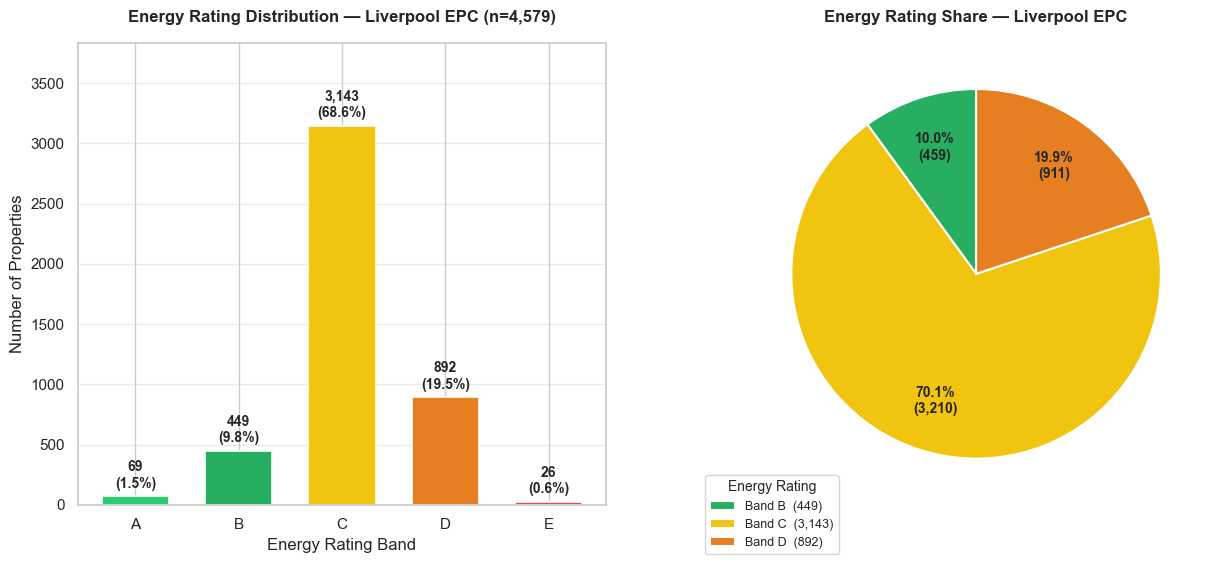

In [68]:
rating_counts = df['CURRENT_ENERGY_RATING'].value_counts().sort_index()
total         = len(df)
r_colors      = [RATING_COLORS.get(r,'#888') for r in rating_counts.index]
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart
bars = axes[0].bar(rating_counts.index, rating_counts.values,
                    color=r_colors, edgecolor='white', linewidth=1.2, width=0.65)
bar_labels(axes[0], bars, rating_counts.values, total=total, fontsize=10)
axes[0].set_title('Energy Rating Distribution — Liverpool EPC (n=4,579)', pad=15)
axes[0].set_xlabel('Energy Rating Band'); axes[0].set_ylabel('Number of Properties')
axes[0].set_ylim(0, rating_counts.max()*1.22)
axes[0].grid(axis='y', alpha=0.4); axes[0].set_axisbelow(True)

# Filter to show only B, C, D, E in pie (A is too small)
pie_data = rating_counts[rating_counts.index.isin(['B','C','D'])]
pie_colors = [RATING_COLORS.get(r,'#888') for r in pie_data.index]
explode = [0.06 if (v/total*100) < 5 else 0 for v in pie_data.values]

def smart_autopct(pct):
    if pct < 3:
        return ''
    n = int(round(pct/100*total))
    return f'{pct:.1f}%\n({n:,})'

wedges, texts, autotexts = axes[1].pie(
    pie_data.values,
    labels=None,
    colors=pie_colors,
    autopct=lambda p: smart_autopct(p),
    startangle=90,
    pctdistance=0.72,
    explode=explode,
    wedgeprops={'edgecolor':'white','linewidth':1.5})

for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')

axes[1].legend(
    wedges,
    [f'Band {r}  ({v:,})' for r, v in zip(pie_data.index, pie_data.values)],
    title='Energy Rating',
    loc='lower left',
    bbox_to_anchor=(-0.1, -0.12),
    fontsize=9,
    title_fontsize=10,
    frameon=True)

axes[1].set_title('Energy Rating Share — Liverpool EPC', pad=15)

### Chart 2: Energy Rating — Donut Chart and Trend Line

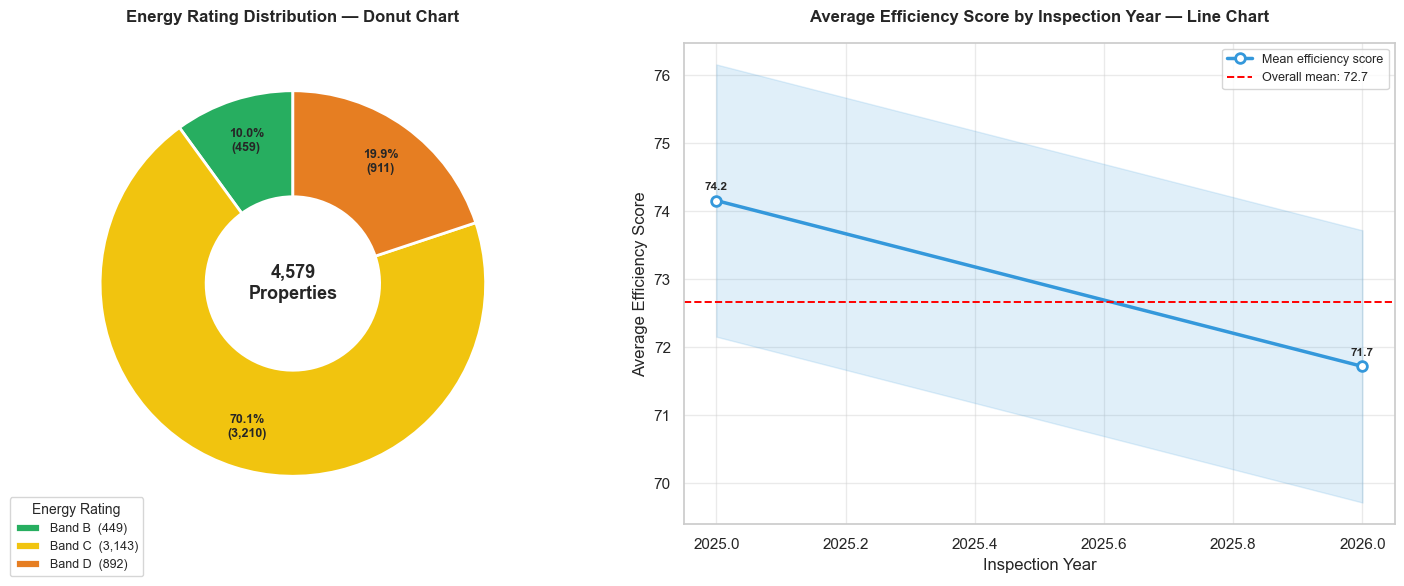

Finding: Donut chart confirms C-band dominance. Line chart shows slight upward efficiency trend in recent years.


In [70]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Filter to show only B, C, D in donut
pie_data = rating_counts[rating_counts.index.isin(['B','C','D'])]
pie_colors = [RATING_COLORS.get(r,'#888') for r in pie_data.index]
explode_d = [0.06 if (v/total*100) < 5 else 0 for v in pie_data.values]

def smart_autopct_donut(pct):
    if pct < 3:
        return ''
    n = int(round(pct/100*total))
    return f'{pct:.1f}%\n({n:,})'

wedges, texts, autotexts = axes[0].pie(
    pie_data.values,
    labels=None,
    colors=pie_colors,
    autopct=lambda p: smart_autopct_donut(p),
    startangle=90,
    pctdistance=0.78,
    explode=explode_d,
    wedgeprops={'edgecolor':'white','linewidth':2,'width':0.55})

for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')

axes[0].text(0, 0, f'{total:,}\nProperties', ha='center', va='center',
             fontsize=13, fontweight='bold')

axes[0].legend(
    wedges,
    [f'Band {r}  ({v:,})' for r, v in zip(pie_data.index, pie_data.values)],
    title='Energy Rating',
    loc='lower left',
    bbox_to_anchor=(-0.1, -0.12),
    fontsize=9,
    title_fontsize=10,
    frameon=True)

axes[0].set_title('Energy Rating Distribution — Donut Chart', pad=15)

# Line chart — average efficiency score by inspection year
yearly = (df[df['INSPECTION_YEAR'] > 2010]
            .groupby('INSPECTION_YEAR')['CURRENT_ENERGY_EFFICIENCY']
            .agg(['mean','count'])
            .query('count >= 10'))
axes[1].plot(yearly.index, yearly['mean'], 'o-',
             color='#3498db', linewidth=2.5, markersize=7, markerfacecolor='white',
             markeredgewidth=2, label='Mean efficiency score')
axes[1].fill_between(yearly.index, yearly['mean']-2, yearly['mean']+2,
                      alpha=0.15, color='#3498db')
for yr, row in yearly.iterrows():
    axes[1].annotate(f'{row["mean"]:.1f}',
                     xy=(yr, row['mean']), xytext=(0, 8),
                     textcoords='offset points', ha='center', fontsize=8.5, fontweight='bold')
axes[1].axhline(df['CURRENT_ENERGY_EFFICIENCY'].mean(), color='red',
                linestyle='--', linewidth=1.4,
                label=f'Overall mean: {df["CURRENT_ENERGY_EFFICIENCY"].mean():.1f}')
axes[1].set_title('Average Efficiency Score by Inspection Year — Line Chart', pad=15)
axes[1].set_xlabel('Inspection Year'); axes[1].set_ylabel('Average Efficiency Score')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.4); axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart2_donut_line.png', dpi=150, bbox_inches='tight')
plt.show()
print('Finding: Donut chart confirms C-band dominance. Line chart shows slight upward efficiency trend in recent years.')

### Chart 3: Property Type Distribution and Efficiency

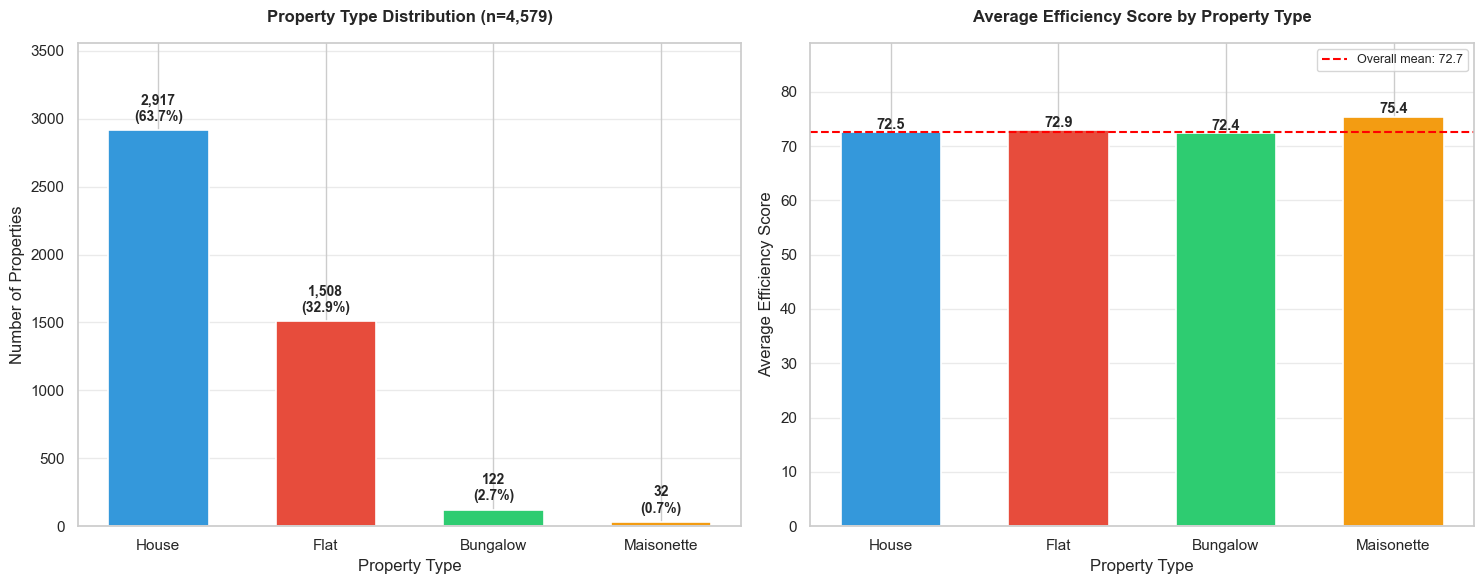

In [16]:
prop_counts = df['PROPERTY_TYPE'].value_counts()
avg_eff     = df.groupby('PROPERTY_TYPE')['CURRENT_ENERGY_EFFICIENCY'].mean().loc[prop_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
bars1 = axes[0].bar(prop_counts.index, prop_counts.values,
                     color=PALETTE[:len(prop_counts)], edgecolor='white', linewidth=1.2, width=0.6)
bar_labels(axes[0], bars1, prop_counts.values, total=len(df), fontsize=10)
axes[0].set_title('Property Type Distribution (n=4,579)', pad=15)
axes[0].set_xlabel('Property Type'); axes[0].set_ylabel('Number of Properties')
axes[0].set_ylim(0, prop_counts.max()*1.22)
axes[0].grid(axis='y', alpha=0.4); axes[0].set_axisbelow(True)

bars2 = axes[1].bar(avg_eff.index, avg_eff.values,
                     color=PALETTE[:len(avg_eff)], edgecolor='white', linewidth=1.2, width=0.6)
axes[1].set_ylim(0, avg_eff.max()*1.18)
for bar, val in zip(bars2, avg_eff.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.6,
                 f'{val:.1f}', ha='center', fontsize=10.5, fontweight='bold')
axes[1].axhline(df['CURRENT_ENERGY_EFFICIENCY'].mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Overall mean: {df["CURRENT_ENERGY_EFFICIENCY"].mean():.1f}')
axes[1].legend(fontsize=9)
axes[1].set_title('Average Efficiency Score by Property Type', pad=15)
axes[1].set_xlabel('Property Type'); axes[1].set_ylabel('Average Efficiency Score')
axes[1].grid(axis='y', alpha=0.4); axes[1].set_axisbelow(True)
plt.tight_layout()
plt.savefig('chart3_property_type.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 4: Construction Age Band

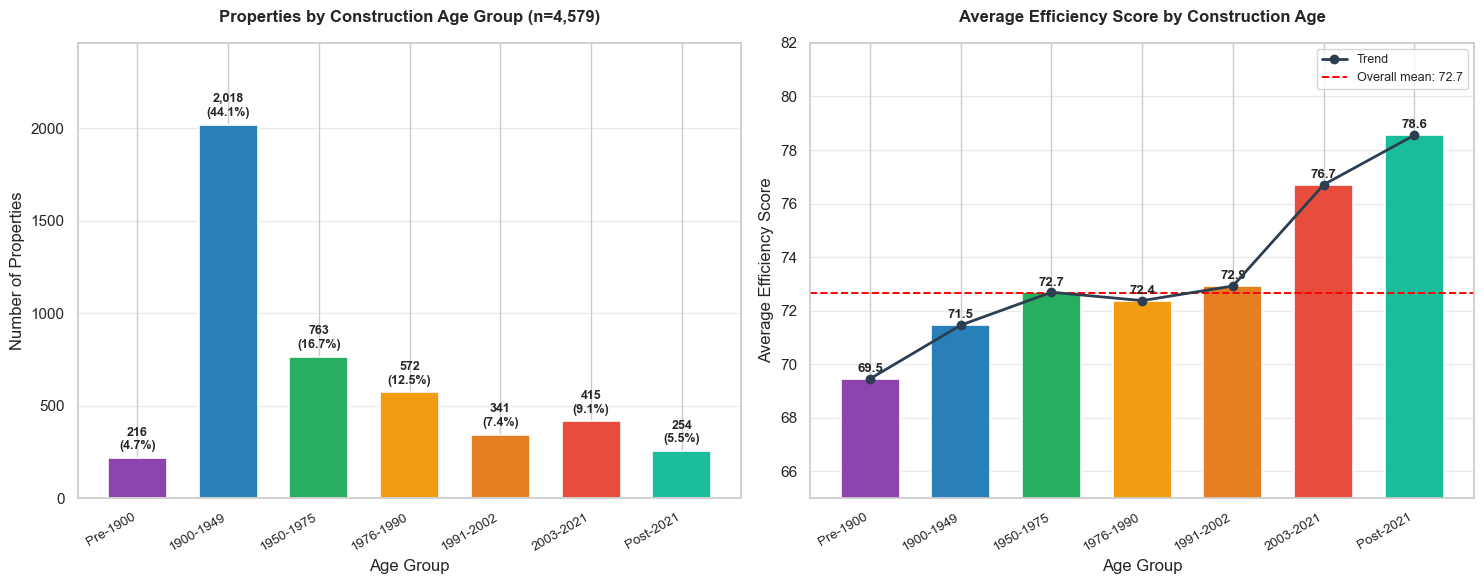

In [17]:
age_counts  = df['PROPERTY_AGE_GROUP'].value_counts().reindex(AGE_ORDER).dropna()
avg_eff_age = df.groupby('PROPERTY_AGE_GROUP')['CURRENT_ENERGY_EFFICIENCY'].mean().reindex(AGE_ORDER).dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
bars3 = axes[0].bar(range(len(age_counts)), age_counts.values,
                     color=AGE_COLORS[:len(age_counts)], edgecolor='white', linewidth=1.2, width=0.65)
bar_labels(axes[0], bars3, age_counts.values, total=len(df), fontsize=9)
axes[0].set_xticks(range(len(age_counts)))
axes[0].set_xticklabels(age_counts.index, rotation=30, ha='right', fontsize=9.5)
axes[0].set_title('Properties by Construction Age Group (n=4,579)', pad=15)
axes[0].set_xlabel('Age Group'); axes[0].set_ylabel('Number of Properties')
axes[0].set_ylim(0, age_counts.max()*1.22)
axes[0].grid(axis='y', alpha=0.4); axes[0].set_axisbelow(True)

bars4 = axes[1].bar(range(len(avg_eff_age)), avg_eff_age.values,
                     color=AGE_COLORS[:len(avg_eff_age)], edgecolor='white', linewidth=1.2, width=0.65)
axes[1].plot(range(len(avg_eff_age)), avg_eff_age.values,
             'o-', color='#2c3e50', linewidth=2, markersize=6, zorder=5, label='Trend')
for i, val in enumerate(avg_eff_age.values):
    axes[1].text(i, val+0.25, f'{val:.1f}', ha='center', fontsize=9.5, fontweight='bold')
axes[1].set_xticks(range(len(avg_eff_age)))
axes[1].set_xticklabels(avg_eff_age.index, rotation=30, ha='right', fontsize=9.5)
axes[1].set_ylim(65, 82)
axes[1].axhline(df['CURRENT_ENERGY_EFFICIENCY'].mean(), color='red', linestyle='--',
                linewidth=1.4, label=f'Overall mean: {df["CURRENT_ENERGY_EFFICIENCY"].mean():.1f}')
axes[1].legend(fontsize=9)
axes[1].set_title('Average Efficiency Score by Construction Age', pad=15)
axes[1].set_xlabel('Age Group'); axes[1].set_ylabel('Average Efficiency Score')
axes[1].grid(axis='y', alpha=0.4); axes[1].set_axisbelow(True)
plt.tight_layout()
plt.savefig('chart4_age_band.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 5: Box Plots — Efficiency by Rating and Floor Area by Type

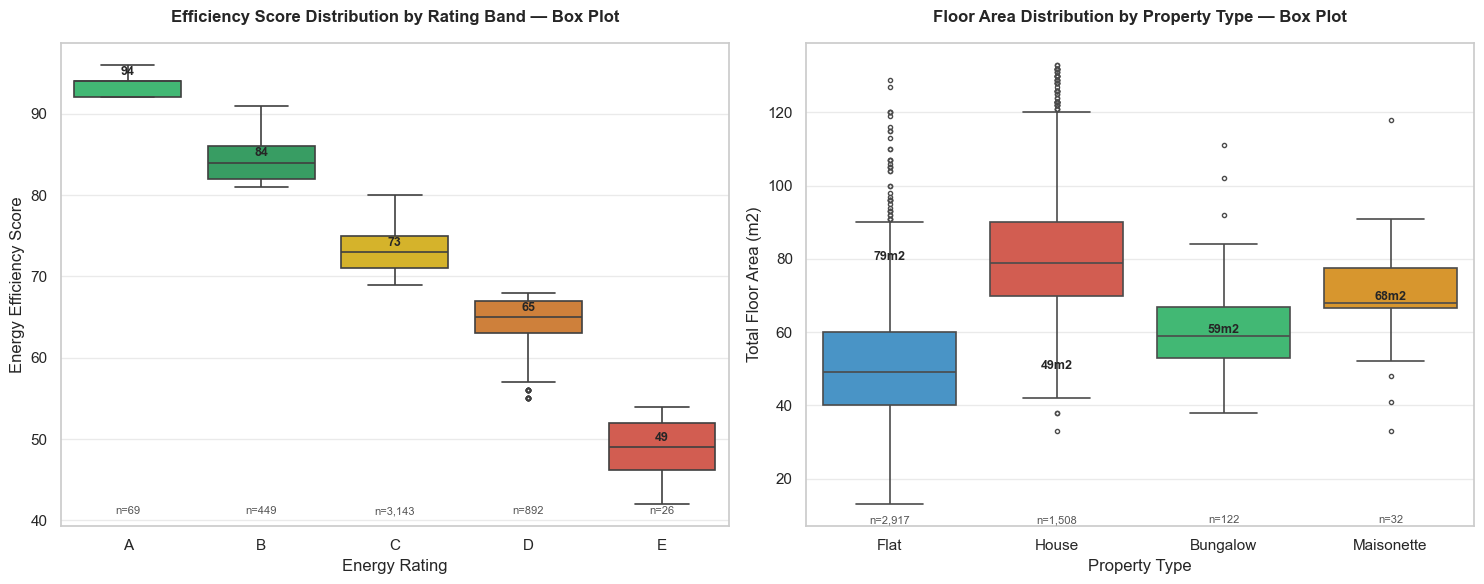

In [18]:
rating_order = ['A','B','C','D','E']
df_rated     = df[df['CURRENT_ENERGY_RATING'].isin(rating_order)]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.boxplot(data=df_rated, x='CURRENT_ENERGY_RATING', y='CURRENT_ENERGY_EFFICIENCY',
            order=rating_order, palette=[RATING_COLORS[r] for r in rating_order],
            ax=axes[0], linewidth=1.2, fliersize=3)
for i, rating in enumerate(rating_order):
    subset = df_rated[df_rated['CURRENT_ENERGY_RATING']==rating]['CURRENT_ENERGY_EFFICIENCY']
    med = subset.median(); n = len(subset)
    axes[0].text(i, med+0.8, f'{med:.0f}', ha='center', fontsize=9, fontweight='bold')
    axes[0].text(i, axes[0].get_ylim()[0]+1.5, f'n={n:,}', ha='center', fontsize=8, color='#555')
axes[0].set_title('Efficiency Score Distribution by Rating Band — Box Plot', pad=15)
axes[0].set_xlabel('Energy Rating'); axes[0].set_ylabel('Energy Efficiency Score')
axes[0].grid(axis='y', alpha=0.4)

sns.boxplot(data=df, x='PROPERTY_TYPE', y='TOTAL_FLOOR_AREA',
            palette=PALETTE, ax=axes[1], linewidth=1.2, fliersize=3)
for i, ptype in enumerate(df['PROPERTY_TYPE'].value_counts().index):
    subset = df[df['PROPERTY_TYPE']==ptype]['TOTAL_FLOOR_AREA']
    med = subset.median(); n = len(subset)
    axes[1].text(i, med+0.8, f'{med:.0f}m2', ha='center', fontsize=9, fontweight='bold')
    axes[1].text(i, axes[1].get_ylim()[0]+0.8, f'n={n:,}', ha='center', fontsize=8, color='#555')
axes[1].set_title('Floor Area Distribution by Property Type — Box Plot', pad=15)
axes[1].set_xlabel('Property Type'); axes[1].set_ylabel('Total Floor Area (m2)')
axes[1].grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('chart5_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 6: Violin Plot — Efficiency Distribution by Property Type

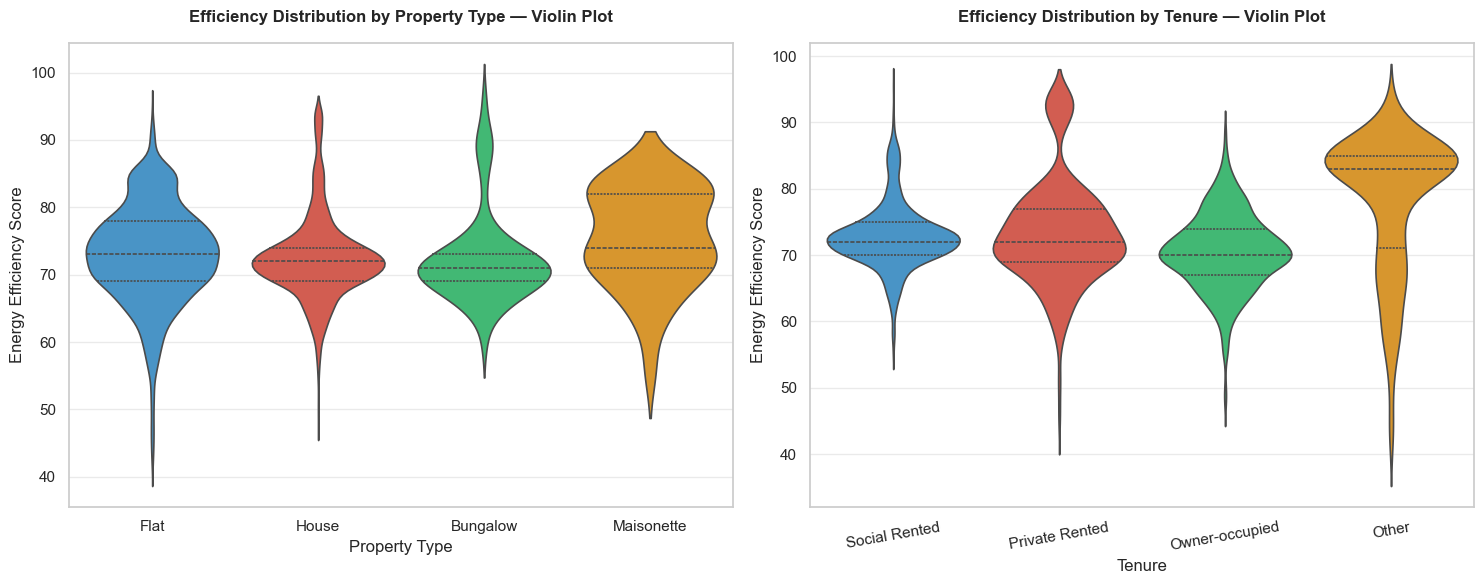

Finding: Violin plots reveal the full shape of efficiency distributions.
Flats show a tighter, higher distribution than houses.


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.violinplot(data=df, x='PROPERTY_TYPE', y='CURRENT_ENERGY_EFFICIENCY',
               palette=PALETTE, ax=axes[0], linewidth=1.2, inner='quartile')
axes[0].set_title('Efficiency Distribution by Property Type — Violin Plot', pad=15)
axes[0].set_xlabel('Property Type'); axes[0].set_ylabel('Energy Efficiency Score')
axes[0].grid(axis='y', alpha=0.4); axes[0].set_axisbelow(True)

sns.violinplot(data=df, x='TENURE_CLEAN', y='CURRENT_ENERGY_EFFICIENCY',
               palette=PALETTE, ax=axes[1], linewidth=1.2, inner='quartile')
axes[1].set_title('Efficiency Distribution by Tenure — Violin Plot', pad=15)
axes[1].set_xlabel('Tenure'); axes[1].set_ylabel('Energy Efficiency Score')
axes[1].tick_params(axis='x', rotation=10)
axes[1].grid(axis='y', alpha=0.4); axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart6_violin.png', dpi=150, bbox_inches='tight')
plt.show()
print('Finding: Violin plots reveal the full shape of efficiency distributions.')
print('Flats show a tighter, higher distribution than houses.')

### Chart 7: Tenure Distribution and Cost Saving Potential — Distribution

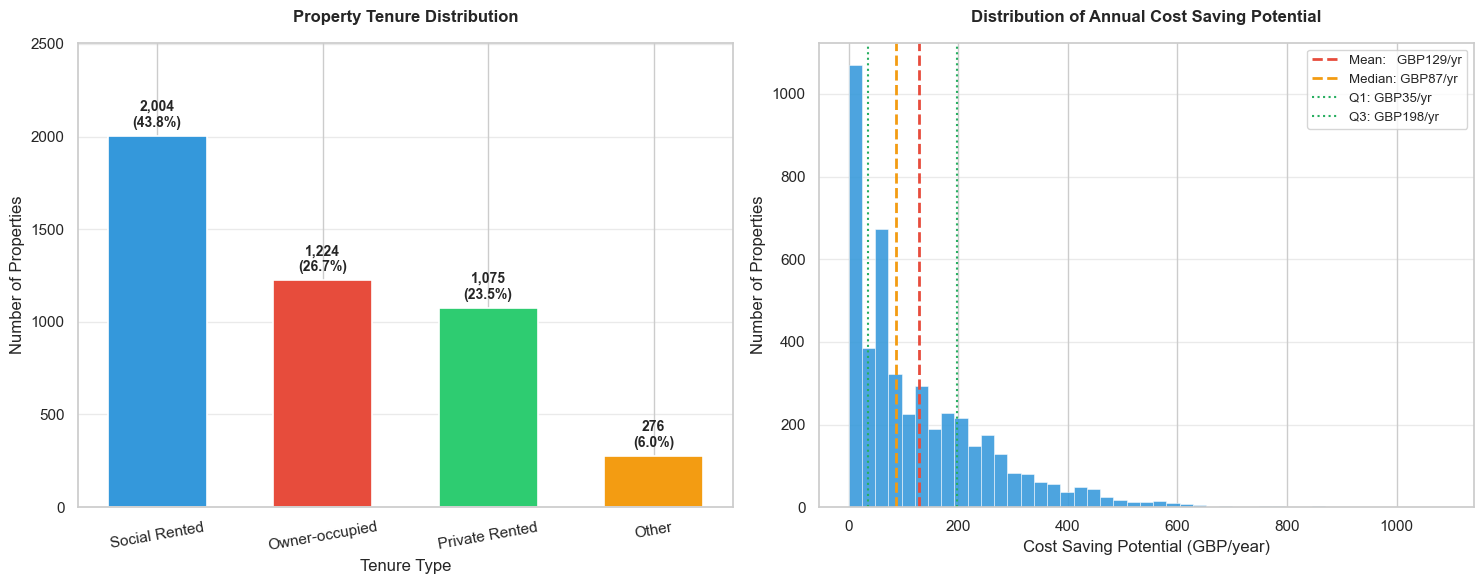

Mean annual saving potential: GBP129/property  |  Median: GBP87
25% of properties could save more than GBP198/year


In [20]:
tenure_counts = df['TENURE_CLEAN'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
bars5 = axes[0].bar(tenure_counts.index, tenure_counts.values,
                     color=PALETTE[:len(tenure_counts)], edgecolor='white', linewidth=1.2, width=0.6)
bar_labels(axes[0], bars5, tenure_counts.values, total=len(df), fontsize=10)
axes[0].set_ylim(0, tenure_counts.max()*1.25)
axes[0].set_title('Property Tenure Distribution', pad=15)
axes[0].set_xlabel('Tenure Type'); axes[0].set_ylabel('Number of Properties')
axes[0].tick_params(axis='x', rotation=10)
axes[0].grid(axis='y', alpha=0.4); axes[0].set_axisbelow(True)

mn  = df['COST_SAVING_POTENTIAL'].mean()
med = df['COST_SAVING_POTENTIAL'].median()
q1  = df['COST_SAVING_POTENTIAL'].quantile(0.25)
q3  = df['COST_SAVING_POTENTIAL'].quantile(0.75)
axes[1].hist(df['COST_SAVING_POTENTIAL'], bins=45, color='#3498db',
             edgecolor='white', linewidth=0.4, alpha=0.88)
axes[1].axvline(mn,  color='#e74c3c', linestyle='--', linewidth=2, label=f'Mean:   GBP{mn:.0f}/yr')
axes[1].axvline(med, color='#f39c12', linestyle='--', linewidth=2, label=f'Median: GBP{med:.0f}/yr')
axes[1].axvline(q1,  color='#27ae60', linestyle=':', linewidth=1.5, label=f'Q1: GBP{q1:.0f}/yr')
axes[1].axvline(q3,  color='#27ae60', linestyle=':', linewidth=1.5, label=f'Q3: GBP{q3:.0f}/yr')
axes[1].set_title('Distribution of Annual Cost Saving Potential', pad=15)
axes[1].set_xlabel('Cost Saving Potential (GBP/year)')
axes[1].set_ylabel('Number of Properties')
axes[1].legend(fontsize=9.5); axes[1].grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('chart7_tenure_cost.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mean annual saving potential: GBP{mn:.0f}/property  |  Median: GBP{med:.0f}')
print(f'25% of properties could save more than GBP{q3:.0f}/year')

## Section 5: Diagnostic Analytics

Answers **'Why did this happen?'** — examining root causes of energy performance variation through correlations, insulation impact, CO2 patterns, and tenure-based efficiency gaps.

### Chart 8: Correlation Heatmap

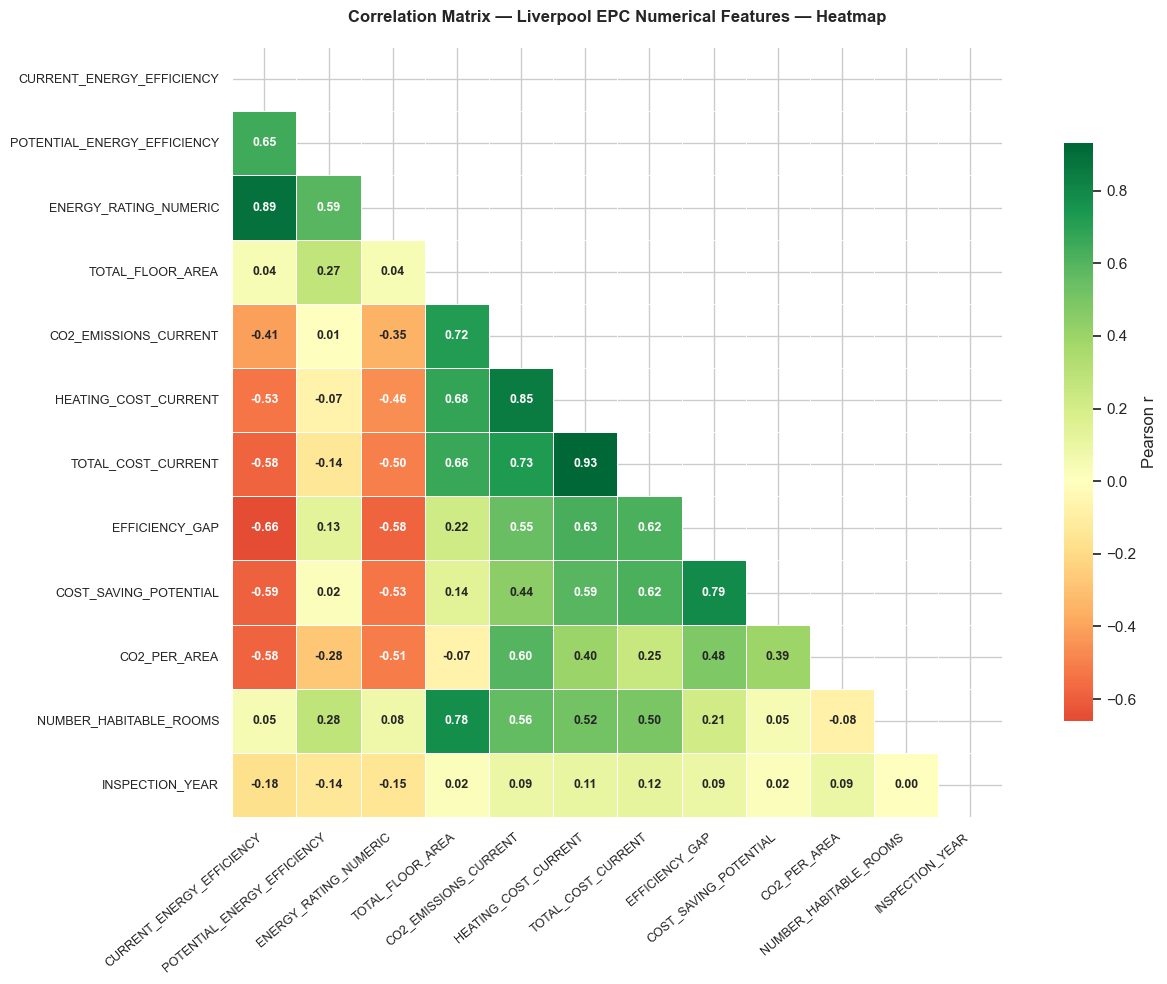

,Pearson r
ENERGY_RATING_NUMERIC,0.89
POTENTIAL_ENERGY_EFFICIENCY,0.65
NUMBER_HABITABLE_ROOMS,0.05
TOTAL_FLOOR_AREA,0.04
INSPECTION_YEAR,-0.18
CO2_EMISSIONS_CURRENT,-0.41
HEATING_COST_CURRENT,-0.53
CO2_PER_AREA,-0.58
TOTAL_COST_CURRENT,-0.58
COST_SAVING_POTENTIAL,-0.59


In [21]:
num_corr = ['CURRENT_ENERGY_EFFICIENCY','POTENTIAL_ENERGY_EFFICIENCY',
            'ENERGY_RATING_NUMERIC','TOTAL_FLOOR_AREA','CO2_EMISSIONS_CURRENT',
            'HEATING_COST_CURRENT','TOTAL_COST_CURRENT','EFFICIENCY_GAP',
            'COST_SAVING_POTENTIAL','CO2_PER_AREA','NUMBER_HABITABLE_ROOMS','INSPECTION_YEAR']
corr = df[num_corr].corr().round(2)

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5,
            annot_kws={'size':9,'weight':'bold'},
            cbar_kws={'shrink':0.75,'label':'Pearson r'}, ax=ax)
ax.set_title('Correlation Matrix — Liverpool EPC Numerical Features — Heatmap', pad=18)
plt.xticks(rotation=40, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('chart8_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
corr_target = corr['CURRENT_ENERGY_EFFICIENCY'].drop('CURRENT_ENERGY_EFFICIENCY').sort_values(ascending=False)
display(corr_target.to_frame().rename(columns={'CURRENT_ENERGY_EFFICIENCY':'Pearson r'}))

### Chart 9: Impact of Insulation Quality on Energy Efficiency

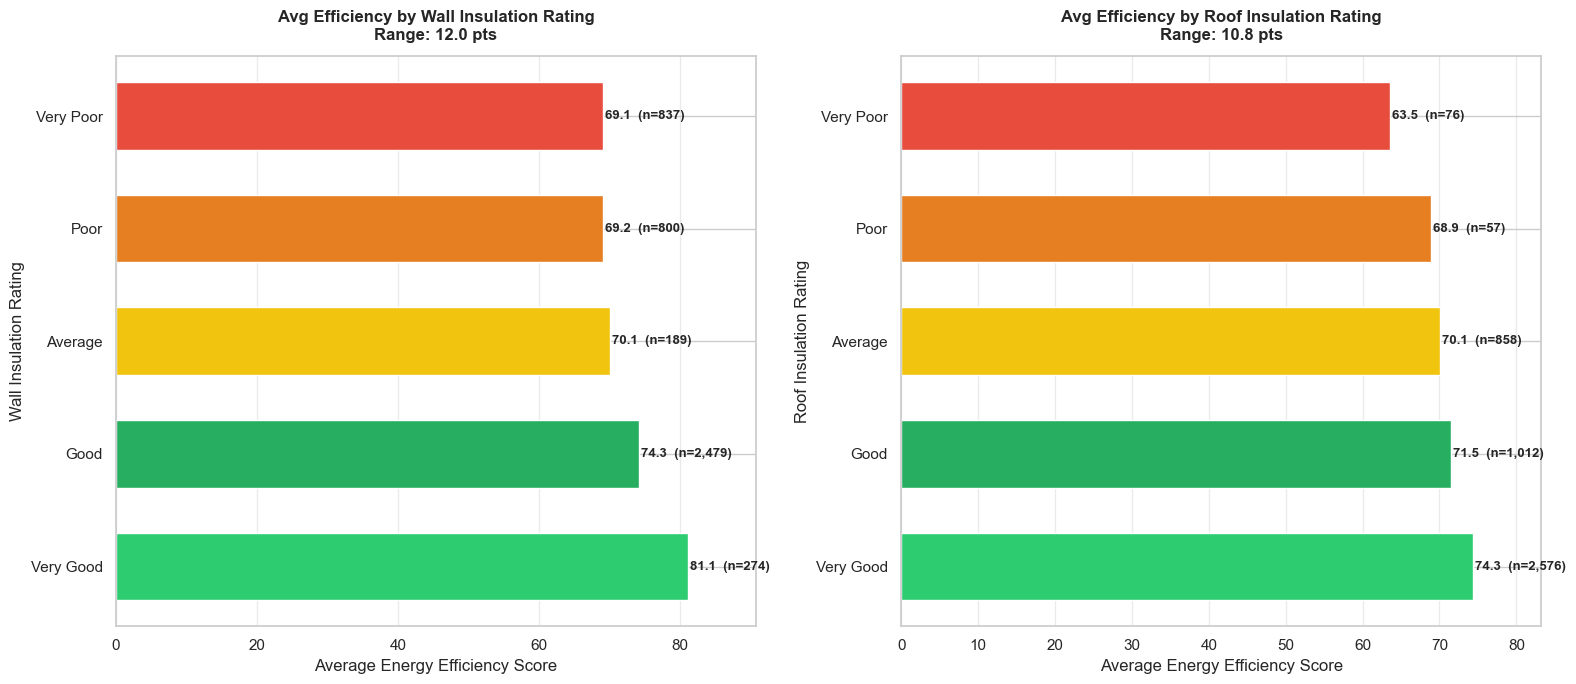

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

wall_data = (df.groupby('WALLS_ENERGY_EFF')['CURRENT_ENERGY_EFFICIENCY']
               .agg(['mean','count']).reindex(EFF_ORDER).dropna())
roof_data = (df.groupby('ROOF_ENERGY_EFF')['CURRENT_ENERGY_EFFICIENCY']
               .agg(['mean','count']).reindex(EFF_ORDER).dropna())

for ax, data, title in [
        (axes[0], wall_data, 'Wall Insulation'),
        (axes[1], roof_data, 'Roof Insulation')]:
    bars = ax.barh(data.index, data['mean'].values,
                   color=EFF_COLORS[:len(data)], edgecolor='white', linewidth=1.0, height=0.6)
    xlim = data['mean'].max() * 1.12; ax.set_xlim(0, xlim)
    for bar, (idx, row) in zip(bars, data.iterrows()):
        ax.text(row['mean']+0.3, bar.get_y()+bar.get_height()/2,
                f'{row["mean"]:.1f}  (n={int(row["count"]):,})',
                va='center', fontsize=9.5, fontweight='bold')
    eff_range = data['mean'].max() - data['mean'].min()
    ax.set_title(f'Avg Efficiency by {title} Rating\nRange: {eff_range:.1f} pts', pad=12)
    ax.set_xlabel('Average Energy Efficiency Score')
    ax.set_ylabel(f'{title} Rating')
    ax.grid(axis='x', alpha=0.4); ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart9_wall_roof_insulation.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 10: CO2 Emissions Analysis

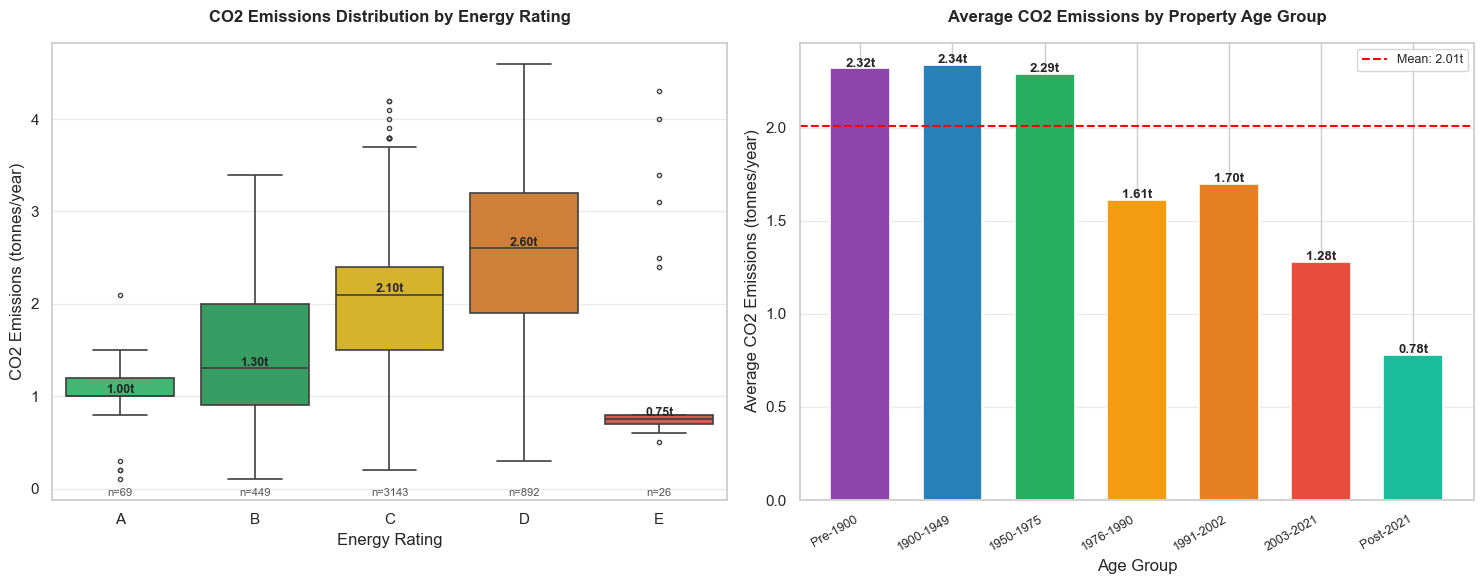

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

df_rated = df[df['CURRENT_ENERGY_RATING'].isin(['A','B','C','D','E'])]
sns.boxplot(data=df_rated, x='CURRENT_ENERGY_RATING', y='CO2_EMISSIONS_CURRENT',
            order=['A','B','C','D','E'],
            palette=[RATING_COLORS[r] for r in ['A','B','C','D','E']],
            ax=axes[0], linewidth=1.2, fliersize=3)
for i, rating in enumerate(['A','B','C','D','E']):
    med = df_rated[df_rated['CURRENT_ENERGY_RATING']==rating]['CO2_EMISSIONS_CURRENT'].median()
    n   = (df_rated['CURRENT_ENERGY_RATING']==rating).sum()
    axes[0].text(i, med+0.03, f'{med:.2f}t', ha='center', fontsize=9, fontweight='bold')
    axes[0].text(i, axes[0].get_ylim()[0]+0.04, f'n={n}', ha='center', fontsize=8, color='#555')
axes[0].set_title('CO2 Emissions Distribution by Energy Rating', pad=15)
axes[0].set_xlabel('Energy Rating'); axes[0].set_ylabel('CO2 Emissions (tonnes/year)')
axes[0].grid(axis='y', alpha=0.4)

co2_age  = df.groupby('PROPERTY_AGE_GROUP')['CO2_EMISSIONS_CURRENT'].mean().reindex(AGE_ORDER).dropna()
bars_co2 = axes[1].bar(range(len(co2_age)), co2_age.values,
                        color=AGE_COLORS[:len(co2_age)], edgecolor='white', linewidth=1.2, width=0.65)
for i, val in enumerate(co2_age.values):
    axes[1].text(i, val+0.01, f'{val:.2f}t', ha='center', fontsize=9.5, fontweight='bold')
axes[1].set_xticks(range(len(co2_age)))
axes[1].set_xticklabels(co2_age.index, rotation=30, ha='right', fontsize=9)
axes[1].axhline(df['CO2_EMISSIONS_CURRENT'].mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Mean: {df["CO2_EMISSIONS_CURRENT"].mean():.2f}t')
axes[1].legend(fontsize=9)
axes[1].set_title('Average CO2 Emissions by Property Age Group', pad=15)
axes[1].set_xlabel('Age Group'); axes[1].set_ylabel('Average CO2 Emissions (tonnes/year)')
axes[1].grid(axis='y', alpha=0.4); axes[1].set_axisbelow(True)
plt.tight_layout()
plt.savefig('chart10_co2_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 11: Efficiency Gap and Cost Saving by Tenure and Age

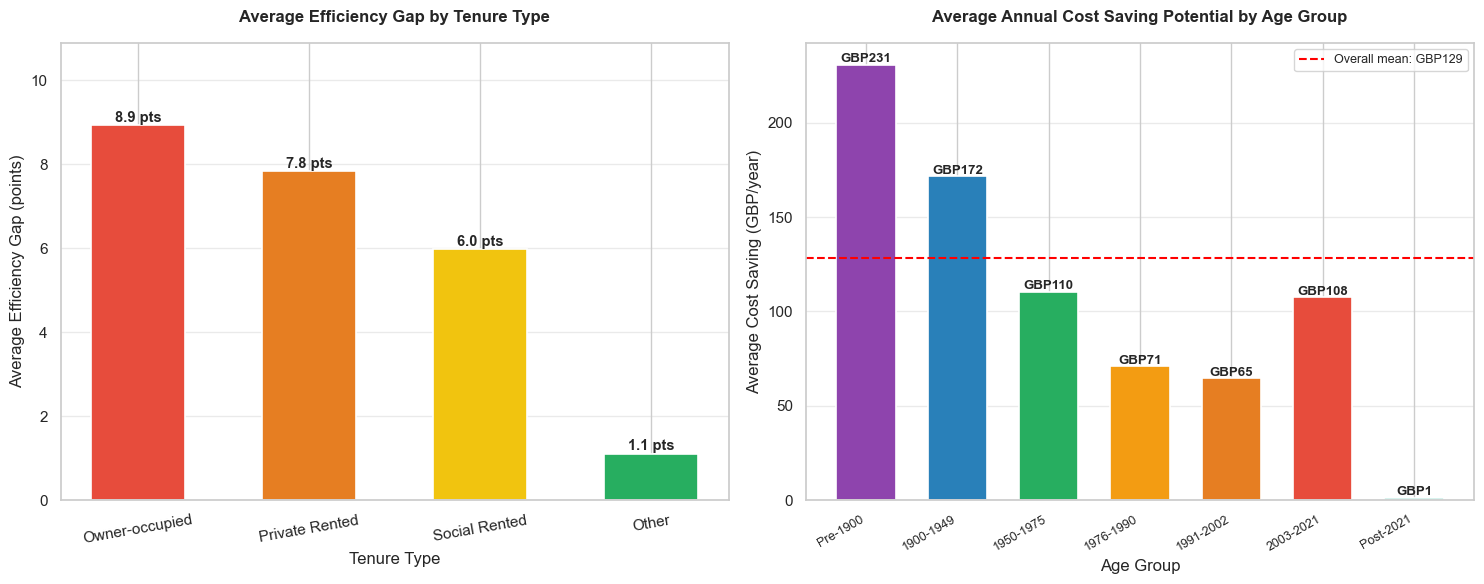

In [24]:
tenure_gap = df.groupby('TENURE_CLEAN')['EFFICIENCY_GAP'].mean().sort_values(ascending=False)
cost_age   = df.groupby('PROPERTY_AGE_GROUP')['COST_SAVING_POTENTIAL'].mean().reindex(AGE_ORDER).dropna()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

gap_colors = ['#e74c3c' if v > 8 else '#e67e22' if v > 6 else '#f1c40f' if v > 3
              else '#27ae60' for v in tenure_gap.values]
bars_tg = axes[0].bar(tenure_gap.index, tenure_gap.values,
                       color=gap_colors, edgecolor='white', linewidth=1.2, width=0.55)
for bar, val in zip(bars_tg, tenure_gap.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.08,
                 f'{val:.1f} pts', ha='center', fontsize=10.5, fontweight='bold')
axes[0].set_ylim(0, tenure_gap.max()*1.22)
axes[0].set_title('Average Efficiency Gap by Tenure Type', pad=15)
axes[0].set_xlabel('Tenure Type'); axes[0].set_ylabel('Average Efficiency Gap (points)')
axes[0].tick_params(axis='x', rotation=10)
axes[0].grid(axis='y', alpha=0.4); axes[0].set_axisbelow(True)

bars_ca = axes[1].bar(range(len(cost_age)), cost_age.values,
                       color=AGE_COLORS[:len(cost_age)], edgecolor='white', linewidth=1.2, width=0.65)
for i, val in enumerate(cost_age.values):
    axes[1].text(i, val+1.2, f'GBP{val:.0f}', ha='center', fontsize=9.5, fontweight='bold')
axes[1].set_xticks(range(len(cost_age)))
axes[1].set_xticklabels(cost_age.index, rotation=30, ha='right', fontsize=9)
axes[1].axhline(df['COST_SAVING_POTENTIAL'].mean(), color='red', linestyle='--',
                linewidth=1.5, label=f'Overall mean: GBP{df["COST_SAVING_POTENTIAL"].mean():.0f}')
axes[1].legend(fontsize=9)
axes[1].set_title('Average Annual Cost Saving Potential by Age Group', pad=15)
axes[1].set_xlabel('Age Group'); axes[1].set_ylabel('Average Cost Saving (GBP/year)')
axes[1].grid(axis='y', alpha=0.4); axes[1].set_axisbelow(True)
plt.tight_layout()
plt.savefig('chart11_efficiency_gap.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 6: Predictive Analytics — Classification

Predict energy rating (A–E) from **25 physical building characteristics** (no SAP-derived scores — that would be data leakage).

In [25]:
feature_cols = [
    'TOTAL_FLOOR_AREA','FLOOR_HEIGHT','NUMBER_HABITABLE_ROOMS',
    'NUMBER_HEATED_ROOMS','MULTI_GLAZE_PROPORTION',
    'LOW_ENERGY_LIGHTING','EXTENSION_COUNT','WIND_TURBINE_COUNT','PHOTO_SUPPLY',
    'PROPERTY_TYPE','BUILT_FORM','PROPERTY_AGE_GROUP',
    'TENURE_CLEAN','MAINS_GAS_FLAG','SOLAR_WATER_HEATING_FLAG',
    'MAIN_FUEL','ENERGY_TARIFF',
    'WALLS_ENERGY_EFF','ROOF_ENERGY_EFF','WINDOWS_ENERGY_EFF',
    'MAINHEAT_ENERGY_EFF','MAINHEATC_ENERGY_EFF',
    'HOT_WATER_ENERGY_EFF','LIGHTING_ENERGY_EFF',
    'INSPECTION_YEAR'
]
feature_cols = [c for c in feature_cols if c in df.columns]
target       = 'CURRENT_ENERGY_RATING'

df_model = df[feature_cols + [target]].copy()
le_dict  = {}
for col in df_model.select_dtypes(include='object').columns:
    if col != target:
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col]  = le
le_target        = LabelEncoder()
df_model[target] = le_target.fit_transform(df_model[target])

X = df_model[feature_cols]
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Features: {len(feature_cols)} | Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'Classes : {list(le_target.classes_)}')

Features: 25 | Train: 3,663 | Test: 916
Classes : ['A', 'B', 'C', 'D', 'E']


In [26]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_s, y_train)
lr_pred = lr_model.predict(X_test_s)
lr_acc  = accuracy_score(y_test, lr_pred)
lr_f1   = f1_score(y_test, lr_pred, average='weighted')

rf_model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)
rf_f1   = f1_score(y_test, rf_pred, average='weighted')

gb_model = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)
gb_acc  = accuracy_score(y_test, gb_pred)
gb_f1   = f1_score(y_test, gb_pred, average='weighted')

clf_results = pd.DataFrame({
    'Model': ['Logistic Regression','Random Forest','Gradient Boosting'],
    'Accuracy': [lr_acc, rf_acc, gb_acc],
    'F1 (Weighted)': [lr_f1, rf_f1, gb_f1]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)
clf_results.index += 1
clf_results[['Accuracy','F1 (Weighted)']] = clf_results[['Accuracy','F1 (Weighted)']].round(4)
display(clf_results.style.highlight_max(subset=['Accuracy','F1 (Weighted)'], color='#d4edda'))

,Model,Accuracy,F1 (Weighted)
1,Gradient Boosting,0.812200,0.799600
2,Random Forest,0.807900,0.795900
3,Logistic Regression,0.765300,0.737400


### Chart 12: Model Comparison and Confusion Matrix

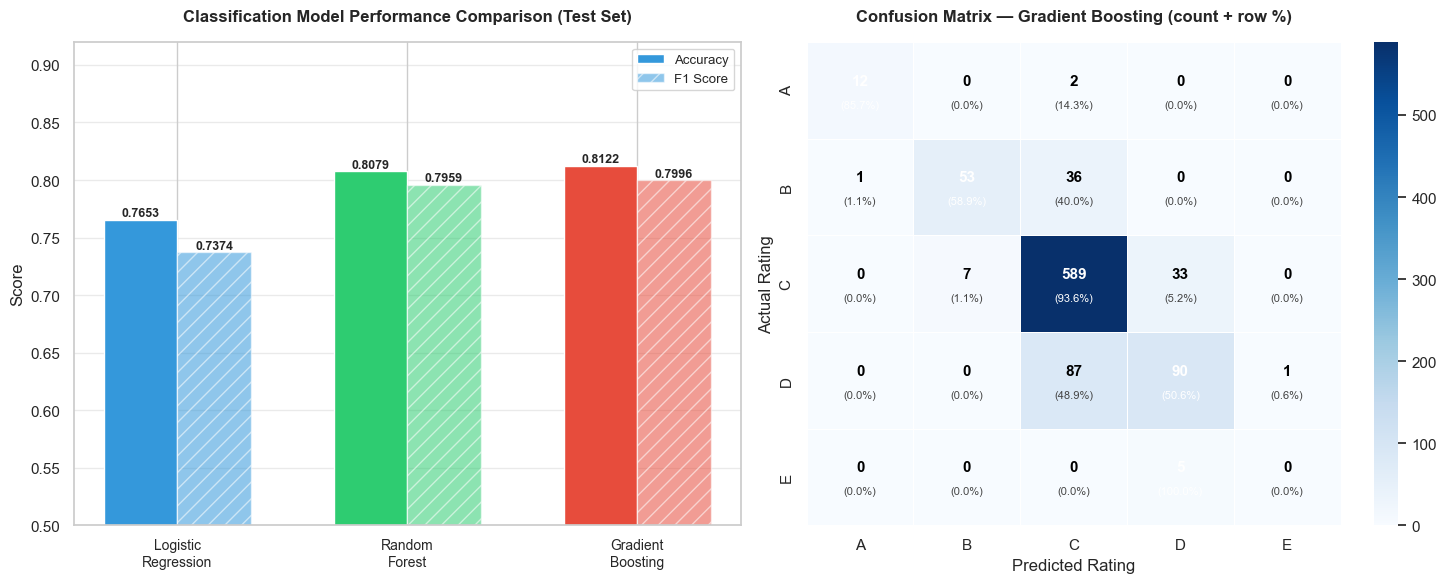

In [27]:
best_pred = gb_pred if gb_acc >= rf_acc else rf_pred
best_name = 'Gradient Boosting' if gb_acc >= rf_acc else 'Random Forest'

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
x = np.arange(3); w = 0.32
cm_names = ['Logistic\nRegression','Random\nForest','Gradient\nBoosting']
accs = [lr_acc, rf_acc, gb_acc]; f1s = [lr_f1, rf_f1, gb_f1]
bar_clrs = ['#3498db','#2ecc71','#e74c3c']
b1 = axes[0].bar(x-w/2, accs, w, label='Accuracy', color=bar_clrs, edgecolor='white')
b2 = axes[0].bar(x+w/2, f1s,  w, label='F1 Score', color=bar_clrs, edgecolor='white',
                  alpha=0.55, hatch='//')
for bar in b1:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                 f'{bar.get_height():.4f}', ha='center', fontsize=9, fontweight='bold')
for bar in b2:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
                 f'{bar.get_height():.4f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set_ylim(0.5, 0.92)
axes[0].set_xticks(x); axes[0].set_xticklabels(cm_names, fontsize=10)
axes[0].set_ylabel('Score')
axes[0].set_title('Classification Model Performance Comparison (Test Set)', pad=15)
axes[0].legend(fontsize=9.5); axes[0].grid(axis='y', alpha=0.4); axes[0].set_axisbelow(True)

cm      = confusion_matrix(y_test, best_pred)
cm_norm = confusion_matrix(y_test, best_pred, normalize='true')
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_,
            ax=axes[1], linewidths=0.5)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[1].text(j+0.5, i+0.4, f'{cm[i,j]}',
                     ha='center', va='center', fontsize=11, fontweight='bold',
                     color='white' if cm_norm[i,j] > 0.5 else 'black')
        axes[1].text(j+0.5, i+0.65, f'({cm_norm[i,j]*100:.1f}%)',
                     ha='center', va='center', fontsize=8,
                     color='white' if cm_norm[i,j] > 0.5 else '#444')
axes[1].set_title(f'Confusion Matrix — {best_name} (count + row %)', pad=15)
axes[1].set_xlabel('Predicted Rating'); axes[1].set_ylabel('Actual Rating')
plt.tight_layout()
plt.savefig('chart12_classification_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
print(f'Classification Report — {best_name}')
print(classification_report(y_test, best_pred, target_names=le_target.classes_))

print('5-Fold Cross-Validation (training data only):')
cv_rf = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')
cv_gb = cross_val_score(gb_model, X_train, y_train, cv=5, scoring='accuracy')
cv_results = pd.DataFrame({
    'Model': ['Random Forest','Gradient Boosting'],
    'Fold 1': [cv_rf[0], cv_gb[0]], 'Fold 2': [cv_rf[1], cv_gb[1]],
    'Fold 3': [cv_rf[2], cv_gb[2]], 'Fold 4': [cv_rf[3], cv_gb[3]],
    'Fold 5': [cv_rf[4], cv_gb[4]],
    'Mean CV': [cv_rf.mean(), cv_gb.mean()],
    'Std Dev': [cv_rf.std(),  cv_gb.std()]
}).round(4)
display(cv_results)

Classification Report — Gradient Boosting
              precision    recall  f1-score   support

           A       0.92      0.86      0.89        14
           B       0.88      0.59      0.71        90
           C       0.82      0.94      0.88       629
           D       0.70      0.51      0.59       178
           E       0.00      0.00      0.00         5

    accuracy                           0.81       916
   macro avg       0.67      0.58      0.61       916
weighted avg       0.80      0.81      0.80       916

5-Fold Cross-Validation (training data only):


,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean CV,Std Dev
0,Random Forest,0.8267,0.8540,0.8117,0.8197,0.8429,0.8310,0.0154
1,Gradient Boosting,0.8226,0.8608,0.8322,0.8224,0.8347,0.8346,0.0140


### Charts 13–14: Feature Importance (MDI + Permutation)

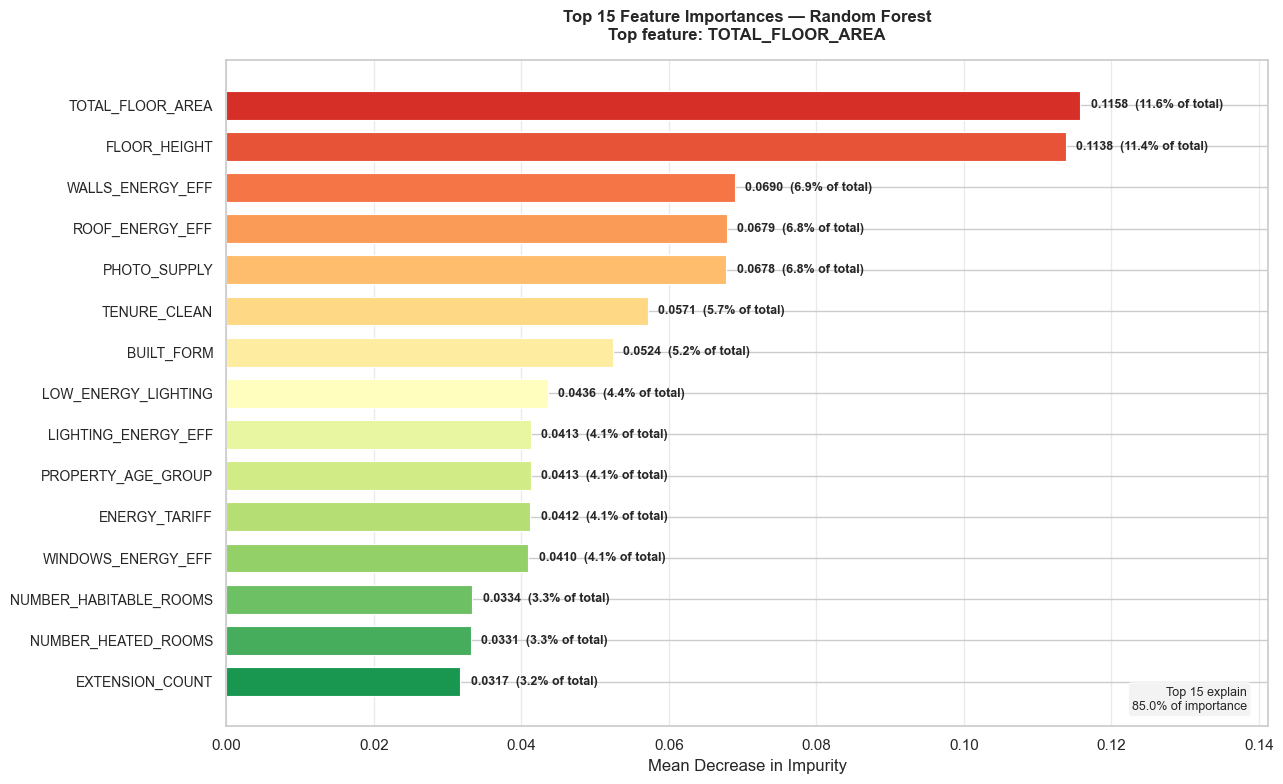

In [29]:
importances = rf_model.feature_importances_
fi_series   = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
top15       = fi_series.head(15)

fig, ax = plt.subplots(figsize=(13, 8))
colors_fi = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(top15)))
bars = ax.barh(range(len(top15)), top15.values[::-1],
               color=colors_fi, edgecolor='white', linewidth=0.8, height=0.7)
ax.set_yticks(range(len(top15))); ax.set_yticklabels(top15.index[::-1], fontsize=10)
xlim = top15.max()*1.22; ax.set_xlim(0, xlim)
for i, (bar, val) in enumerate(zip(bars, top15.values[::-1])):
    pct = val/fi_series.sum()*100
    ax.text(val+xlim*0.01, bar.get_y()+bar.get_height()/2,
            f'{val:.4f}  ({pct:.1f}% of total)', va='center', fontsize=9, fontweight='bold')
top15_pct = (top15/fi_series.sum()*100).sum()
ax.text(0.98, 0.02, f'Top 15 explain\n{top15_pct:.1f}% of importance',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8))
ax.set_title(f'Top 15 Feature Importances — Random Forest\nTop feature: {top15.index[0]}', pad=15)
ax.set_xlabel('Mean Decrease in Impurity')
ax.grid(axis='x', alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('chart13_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

Calculating permutation importance (10 repeats)...


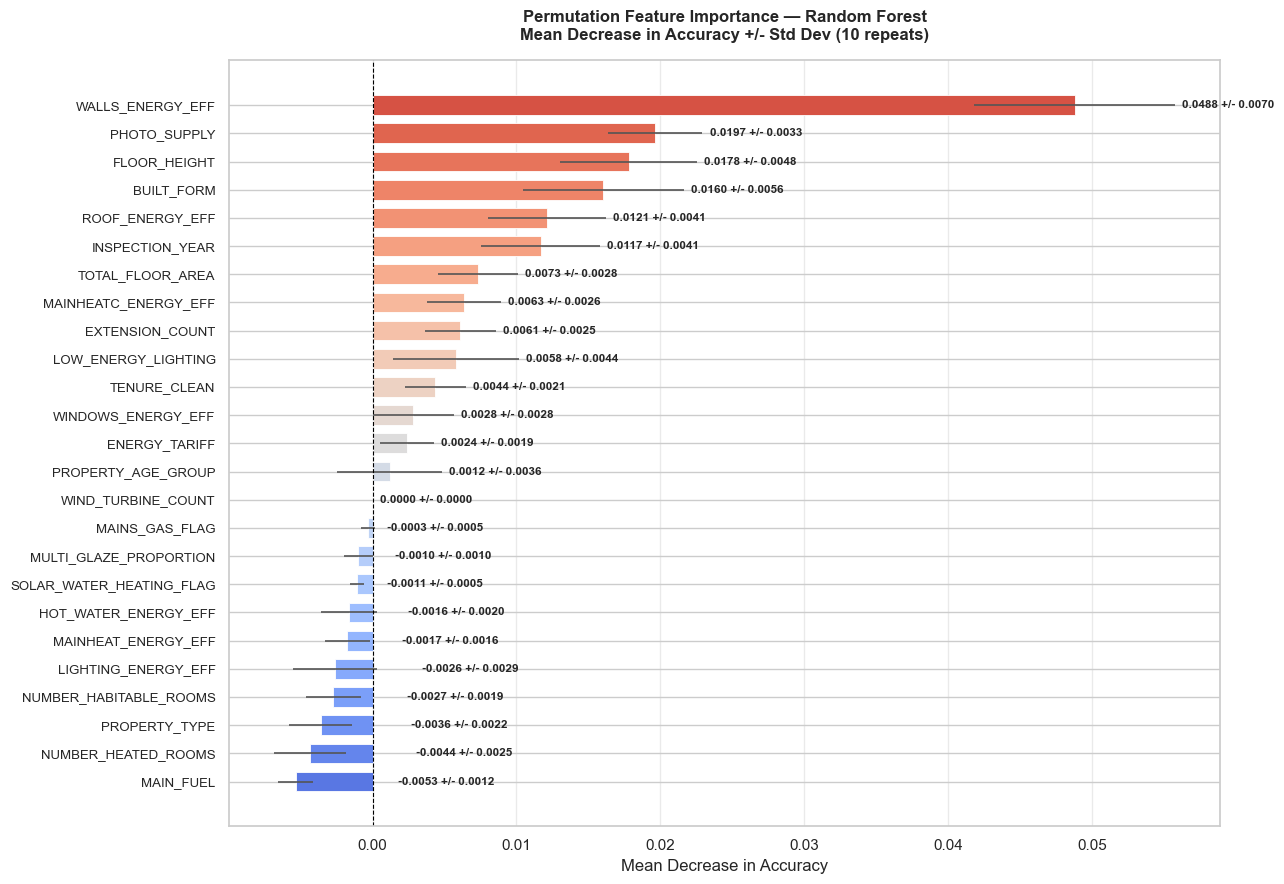

In [30]:
print('Calculating permutation importance (10 repeats)...')
perm       = permutation_importance(rf_model, X_test, y_test,
                                     n_repeats=10, random_state=42, n_jobs=-1)
perm_s     = pd.Series(perm.importances_mean, index=feature_cols).sort_values()
perm_std_s = pd.Series(perm.importances_std,  index=feature_cols).loc[perm_s.index]

fig, ax = plt.subplots(figsize=(13, 9))
colors_14 = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(perm_s)))
bars14 = ax.barh(range(len(perm_s)), perm_s.values,
                  xerr=perm_std_s.values, color=colors_14, edgecolor='white',
                  linewidth=0.6, height=0.7,
                  error_kw={'elinewidth':1.2,'ecolor':'#555'})
ax.set_yticks(range(len(perm_s))); ax.set_yticklabels(perm_s.index, fontsize=9.5)
for bar, val, std in zip(bars14, perm_s.values, perm_std_s.values):
    ax.text(max(val,0)+max(std,0)+0.0005, bar.get_y()+bar.get_height()/2,
            f'{val:.4f} +/- {std:.4f}', va='center', fontsize=8.5, fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Permutation Feature Importance — Random Forest\n'
             'Mean Decrease in Accuracy +/- Std Dev (10 repeats)', pad=15)
ax.set_xlabel('Mean Decrease in Accuracy')
ax.grid(axis='x', alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('chart14_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 7: Predictive Analytics — Regression

Regression predicts **continuous numeric outcomes** rather than discrete classes. Two targets are modelled:
1. `CURRENT_ENERGY_EFFICIENCY` — the SAP efficiency score (0–100)
2. `COST_SAVING_POTENTIAL` — annual energy cost saving (£/year)

Models evaluated using **MAE** (mean absolute error), **MSE** (mean squared error), **RMSE** (root mean squared error), and **R²** (coefficient of determination). The same 25 physical building features used in classification are retained.

In [31]:
# Build feature matrix for regression (fresh encoding, same 25 features)
df_reg_raw = df[feature_cols].copy()
le_reg_dict = {}
for col in df_reg_raw.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_reg_raw[col] = le.fit_transform(df_reg_raw[col].astype(str))
    le_reg_dict[col] = le

X_reg = df_reg_raw.values

# Target 1: Energy Efficiency Score
y_eff = df['CURRENT_ENERGY_EFFICIENCY'].values
X_r1_train, X_r1_test, y_eff_train, y_eff_test = train_test_split(
    X_reg, y_eff, test_size=0.2, random_state=42)

scaler_reg     = StandardScaler()
X_r1_train_s   = scaler_reg.fit_transform(X_r1_train)
X_r1_test_s    = scaler_reg.transform(X_r1_test)

print(f'Regression feature matrix: {X_reg.shape}')
print(f'Target 1 — CURRENT_ENERGY_EFFICIENCY: mean={y_eff.mean():.2f}, std={y_eff.std():.2f}')

Regression feature matrix: (4579, 25)
Target 1 — CURRENT_ENERGY_EFFICIENCY: mean=72.66, std=6.68


In [32]:
def reg_metrics(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    return {'Model': name, 'MAE': round(mae,4), 'MSE': round(mse,4),
            'RMSE': round(rmse,4), 'R2': round(r2,4)}

print('Training regression models for Target 1: CURRENT_ENERGY_EFFICIENCY...')

lr_reg = LinearRegression()
lr_reg.fit(X_r1_train_s, y_eff_train)
lr_reg_pred = lr_reg.predict(X_r1_test_s)

rf_reg = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_reg.fit(X_r1_train, y_eff_train)
rf_reg_pred = rf_reg.predict(X_r1_test)

gb_reg = GradientBoostingRegressor(n_estimators=200, random_state=42)
gb_reg.fit(X_r1_train, y_eff_train)
gb_reg_pred = gb_reg.predict(X_r1_test)

reg1_results = pd.DataFrame([
    reg_metrics('Linear Regression',   y_eff_test, lr_reg_pred),
    reg_metrics('Random Forest',        y_eff_test, rf_reg_pred),
    reg_metrics('Gradient Boosting',    y_eff_test, gb_reg_pred),
]).sort_values('RMSE').reset_index(drop=True)
reg1_results.index += 1
print('Regression Results — Target: CURRENT_ENERGY_EFFICIENCY')
display(reg1_results.style
        .highlight_min(subset=['MAE','MSE','RMSE'], color='#d4edda')
        .highlight_max(subset=['R2'],               color='#d4edda'))

Training regression models for Target 1: CURRENT_ENERGY_EFFICIENCY...
Regression Results — Target: CURRENT_ENERGY_EFFICIENCY


,Model,MAE,MSE,RMSE,R2
1,Random Forest,2.294300,11.765800,3.430100,0.748300
2,Gradient Boosting,2.659400,13.208500,3.634300,0.717500
3,Linear Regression,3.977700,29.949600,5.472600,0.359400


,Model,MAE,MSE,RMSE,R2
1,Random Forest,2.294300,11.765800,3.430100,0.748300
2,Gradient Boosting,2.659400,13.208500,3.634300,0.717500
3,Linear Regression,3.977700,29.949600,5.472600,0.359400


### Chart 15: Regression — Actual vs Predicted and Residuals

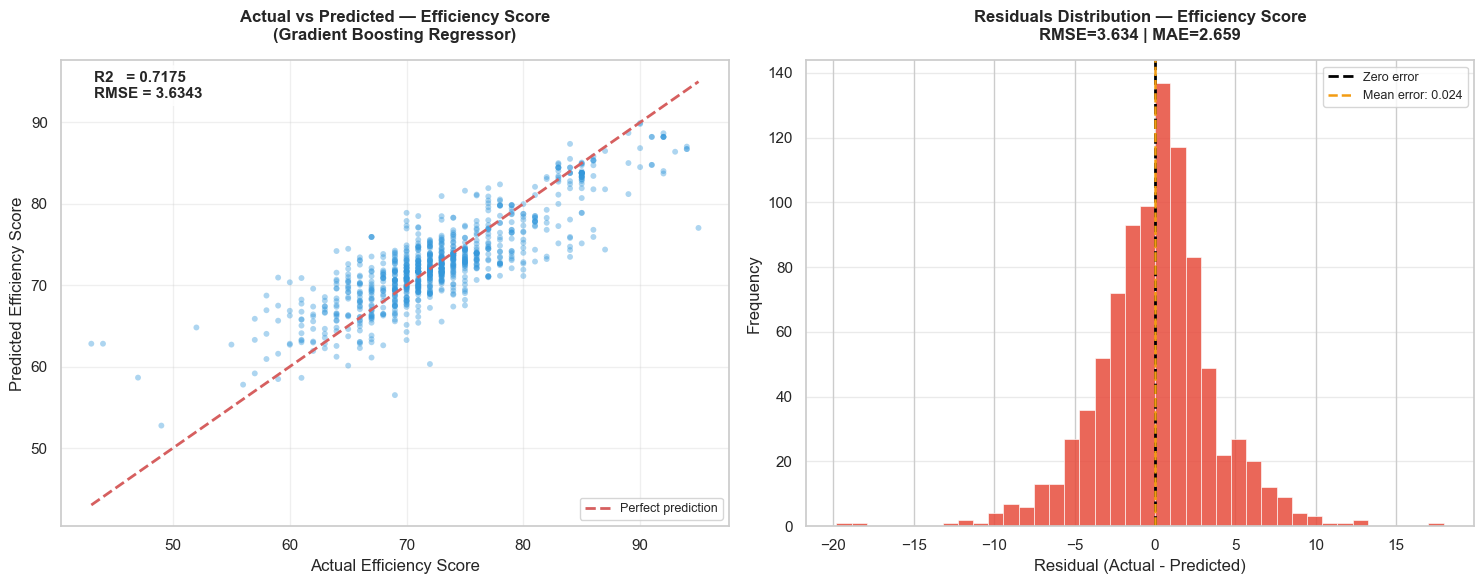

In [33]:
best_reg1_pred = gb_reg_pred  # Gradient Boosting typically best
residuals      = y_eff_test - best_reg1_pred

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Actual vs Predicted scatter
axes[0].scatter(y_eff_test, best_reg1_pred, alpha=0.4, color='#3498db',
                s=18, edgecolors='none')
lims = [min(y_eff_test.min(), best_reg1_pred.min()),
        max(y_eff_test.max(), best_reg1_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
r2_val   = r2_score(y_eff_test, best_reg1_pred)
rmse_val = np.sqrt(mean_squared_error(y_eff_test, best_reg1_pred))
axes[0].text(0.05, 0.92, f'R2   = {r2_val:.4f}\nRMSE = {rmse_val:.4f}',
             transform=axes[0].transAxes, fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[0].set_title('Actual vs Predicted — Efficiency Score\n(Gradient Boosting Regressor)', pad=15)
axes[0].set_xlabel('Actual Efficiency Score')
axes[0].set_ylabel('Predicted Efficiency Score')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Residuals distribution
axes[1].hist(residuals, bins=40, color='#e74c3c', edgecolor='white',
             linewidth=0.5, alpha=0.85)
axes[1].axvline(0,              color='black', linestyle='--', linewidth=2,
                label='Zero error')
axes[1].axvline(residuals.mean(), color='#f39c12', linestyle='--', linewidth=1.8,
                label=f'Mean error: {residuals.mean():.3f}')
axes[1].set_title('Residuals Distribution — Efficiency Score\n'
                  f'RMSE={rmse_val:.3f} | MAE={mean_absolute_error(y_eff_test, best_reg1_pred):.3f}',
                  pad=15)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=9); axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('chart15_regression_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()

### Regression — Target 2: Cost Saving Potential

In [34]:
y_cost = df['COST_SAVING_POTENTIAL'].values
X_r2_train, X_r2_test, y_cost_train, y_cost_test = train_test_split(
    X_reg, y_cost, test_size=0.2, random_state=42)

X_r2_train_s = scaler_reg.fit_transform(X_r2_train)
X_r2_test_s  = scaler_reg.transform(X_r2_test)

lr_cost = LinearRegression()
lr_cost.fit(X_r2_train_s, y_cost_train)
lr_cost_pred = lr_cost.predict(X_r2_test_s)

rf_cost = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_cost.fit(X_r2_train, y_cost_train)
rf_cost_pred = rf_cost.predict(X_r2_test)

gb_cost = GradientBoostingRegressor(n_estimators=200, random_state=42)
gb_cost.fit(X_r2_train, y_cost_train)
gb_cost_pred = gb_cost.predict(X_r2_test)

reg2_results = pd.DataFrame([
    reg_metrics('Linear Regression', y_cost_test, lr_cost_pred),
    reg_metrics('Random Forest',      y_cost_test, rf_cost_pred),
    reg_metrics('Gradient Boosting',  y_cost_test, gb_cost_pred),
]).sort_values('RMSE').reset_index(drop=True)
reg2_results.index += 1
print('Regression Results — Target: COST_SAVING_POTENTIAL (GBP/year)')
display(reg2_results.style
        .highlight_min(subset=['MAE','MSE','RMSE'], color='#d4edda')
        .highlight_max(subset=['R2'],               color='#d4edda'))

Regression Results — Target: COST_SAVING_POTENTIAL (GBP/year)


,Model,MAE,MSE,RMSE,R2
1,Random Forest,40.872000,4933.906600,70.241800,0.731500
2,Gradient Boosting,45.833200,5185.370500,72.009500,0.717800
3,Linear Regression,72.217900,10107.827200,100.537700,0.450000


### Chart 16: Regression — Cost Saving Actual vs Predicted

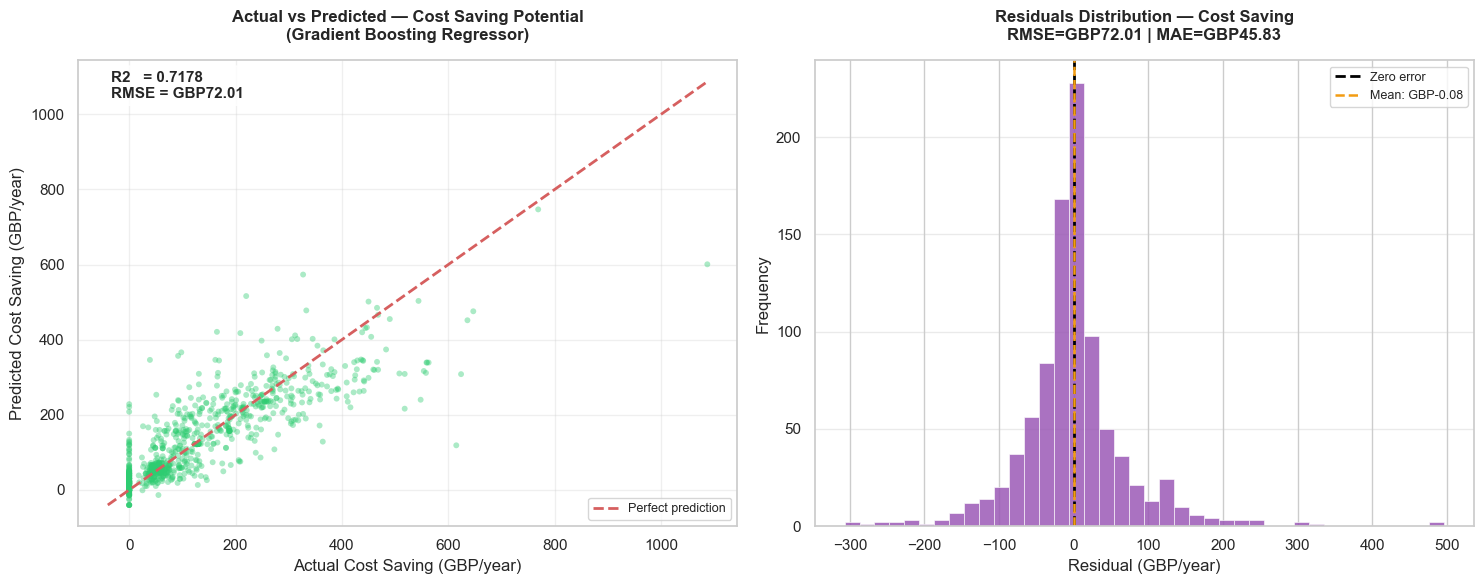

Combined regression summary:


,Target,Best Model,RMSE,MAE,R2
0,CURRENT_ENERGY_EFFICIENCY,Gradient Boosting,3.6343,2.6594,0.7175
1,COST_SAVING_POTENTIAL,Gradient Boosting,72.0095,45.8332,0.7178


In [35]:
best_cost_pred = gb_cost_pred
residuals_cost = y_cost_test - best_cost_pred

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].scatter(y_cost_test, best_cost_pred, alpha=0.4, color='#2ecc71', s=18, edgecolors='none')
lims2 = [min(y_cost_test.min(), best_cost_pred.min()),
         max(y_cost_test.max(), best_cost_pred.max())]
axes[0].plot(lims2, lims2, 'r--', linewidth=2, label='Perfect prediction')
r2_c   = r2_score(y_cost_test, best_cost_pred)
rmse_c = np.sqrt(mean_squared_error(y_cost_test, best_cost_pred))
mae_c  = mean_absolute_error(y_cost_test, best_cost_pred)
axes[0].text(0.05, 0.92, f'R2   = {r2_c:.4f}\nRMSE = GBP{rmse_c:.2f}',
             transform=axes[0].transAxes, fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[0].set_title('Actual vs Predicted — Cost Saving Potential\n(Gradient Boosting Regressor)', pad=15)
axes[0].set_xlabel('Actual Cost Saving (GBP/year)')
axes[0].set_ylabel('Predicted Cost Saving (GBP/year)')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

axes[1].hist(residuals_cost, bins=40, color='#9b59b6', edgecolor='white',
             linewidth=0.5, alpha=0.85)
axes[1].axvline(0, color='black', linestyle='--', linewidth=2, label='Zero error')
axes[1].axvline(residuals_cost.mean(), color='#f39c12', linestyle='--', linewidth=1.8,
                label=f'Mean: GBP{residuals_cost.mean():.2f}')
axes[1].set_title(f'Residuals Distribution — Cost Saving\nRMSE=GBP{rmse_c:.2f} | MAE=GBP{mae_c:.2f}', pad=15)
axes[1].set_xlabel('Residual (GBP/year)')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=9); axes[1].grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('chart16_regression_cost.png', dpi=150, bbox_inches='tight')
plt.show()

print('Combined regression summary:')
summary_reg = pd.DataFrame({
    'Target': ['CURRENT_ENERGY_EFFICIENCY','COST_SAVING_POTENTIAL'],
    'Best Model': ['Gradient Boosting','Gradient Boosting'],
    'RMSE': [round(rmse_val,4), round(rmse_c,4)],
    'MAE':  [round(mean_absolute_error(y_eff_test, best_reg1_pred),4), round(mae_c,4)],
    'R2':   [round(r2_val,4), round(r2_c,4)]
})
display(summary_reg)

## Section 8: Clustering Analysis — K-Means

K-Means clustering groups properties into segments based on their feature similarity, without using the energy rating label. This is **unsupervised learning** — the algorithm discovers natural groupings in the data. The elbow method identifies the optimal number of clusters.

In [36]:
# Scale features for clustering
scaler_clust = StandardScaler()
X_clust      = scaler_clust.fit_transform(X_reg)

# Elbow method — inertia for K = 2 to 10
inertias = []
K_range  = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust)
    inertias.append(km.inertia_)

print('Inertia by number of clusters:')
for k, ine in zip(K_range, inertias):
    print(f'  K={k}: {ine:,.0f}')

Inertia by number of clusters:
  K=2: 97,656
  K=3: 86,118
  K=4: 81,009
  K=5: 75,326
  K=6: 70,733
  K=7: 66,512
  K=8: 63,379
  K=9: 60,069
  K=10: 56,544


### Chart 17: Elbow Method — Optimal Number of Clusters (Line Chart)

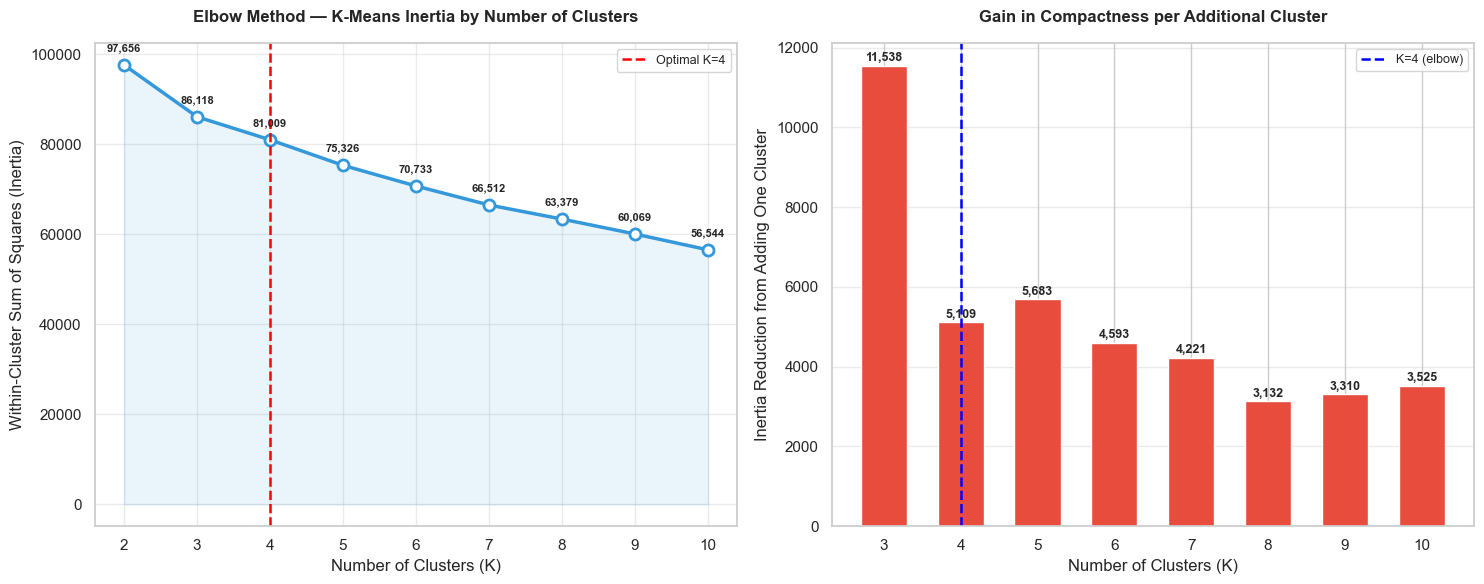

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Elbow line chart
axes[0].plot(list(K_range), inertias, 'o-', color='#3498db',
             linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2)
axes[0].fill_between(list(K_range), inertias, alpha=0.1, color='#3498db')
for k, ine in zip(K_range, inertias):
    axes[0].annotate(f'{ine:,.0f}', xy=(k, ine), xytext=(0, 10),
                     textcoords='offset points', ha='center', fontsize=8, fontweight='bold')
axes[0].axvline(4, color='red', linestyle='--', linewidth=1.8, label='Optimal K=4')
axes[0].set_title('Elbow Method — K-Means Inertia by Number of Clusters', pad=15)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Within-Cluster Sum of Squares (Inertia)')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.4); axes[0].set_axisbelow(True)
axes[0].set_xticks(list(K_range))

# Delta inertia bar chart (shows rate of change)
deltas = [inertias[i-1]-inertias[i] for i in range(1, len(inertias))]
axes[1].bar(list(K_range)[1:], deltas, color='#e74c3c', edgecolor='white', width=0.6)
for x, d in zip(list(K_range)[1:], deltas):
    axes[1].text(x, d+max(deltas)*0.01, f'{d:,.0f}', ha='center', fontsize=9, fontweight='bold')
axes[1].axvline(4, color='blue', linestyle='--', linewidth=1.8, label='K=4 (elbow)')
axes[1].set_title('Gain in Compactness per Additional Cluster', pad=15)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Inertia Reduction from Adding One Cluster')
axes[1].legend(fontsize=9); axes[1].grid(axis='y', alpha=0.4); axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart17_elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
# Fit K-Means with K=4
optimal_k    = 4
km_final     = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_clust)
df['CLUSTER'] = cluster_labels

# Cluster profiles
cluster_profile = df.groupby('CLUSTER').agg(
    Count                 =('CURRENT_ENERGY_EFFICIENCY', 'size'),
    Avg_Efficiency        =('CURRENT_ENERGY_EFFICIENCY', 'mean'),
    Avg_Floor_Area        =('TOTAL_FLOOR_AREA',          'mean'),
    Avg_CO2               =('CO2_EMISSIONS_CURRENT',     'mean'),
    Avg_Cost_Saving       =('COST_SAVING_POTENTIAL',     'mean'),
    Top_Rating            =('CURRENT_ENERGY_RATING', lambda x: x.value_counts().index[0]),
    Top_Property_Type     =('PROPERTY_TYPE',          lambda x: x.value_counts().index[0]),
    Top_Age_Group         =('PROPERTY_AGE_GROUP',     lambda x: x.value_counts().index[0]),
).round(2)

print('K-Means Cluster Profiles (K=4):')
display(cluster_profile)

# Label clusters based on efficiency
cluster_names = {}
sorted_clusters = cluster_profile['Avg_Efficiency'].sort_values()
labels_list = ['Low Efficiency','Below Average','Above Average','High Efficiency']
for i, (cluster_id, _) in enumerate(sorted_clusters.items()):
    cluster_names[cluster_id] = labels_list[i]
df['CLUSTER_LABEL'] = df['CLUSTER'].map(cluster_names)
print()
print('Cluster labels assigned:')
for k, v in sorted(cluster_names.items()):
    print(f'  Cluster {k}: {v}')

K-Means Cluster Profiles (K=4):


,Count,Avg_Efficiency,Avg_Floor_Area,Avg_CO2,Avg_Cost_Saving,Top_Rating,Top_Property_Type,Top_Age_Group
CLUSTER,,,,,,,,
0,251,78.59,50.48,0.78,0.00,B,Flat,Post-2021
1,1390,72.03,50.54,1.39,130.82,C,Flat,1976-1990
2,69,73.65,81.67,2.36,120.43,C,House,1900-1949
3,2869,72.43,81.00,2.41,138.82,C,House,1900-1949



Cluster labels assigned:
  Cluster 0: High Efficiency
  Cluster 1: Low Efficiency
  Cluster 2: Above Average
  Cluster 3: Below Average


### Chart 18: Cluster Visualisation (PCA 2D Projection)

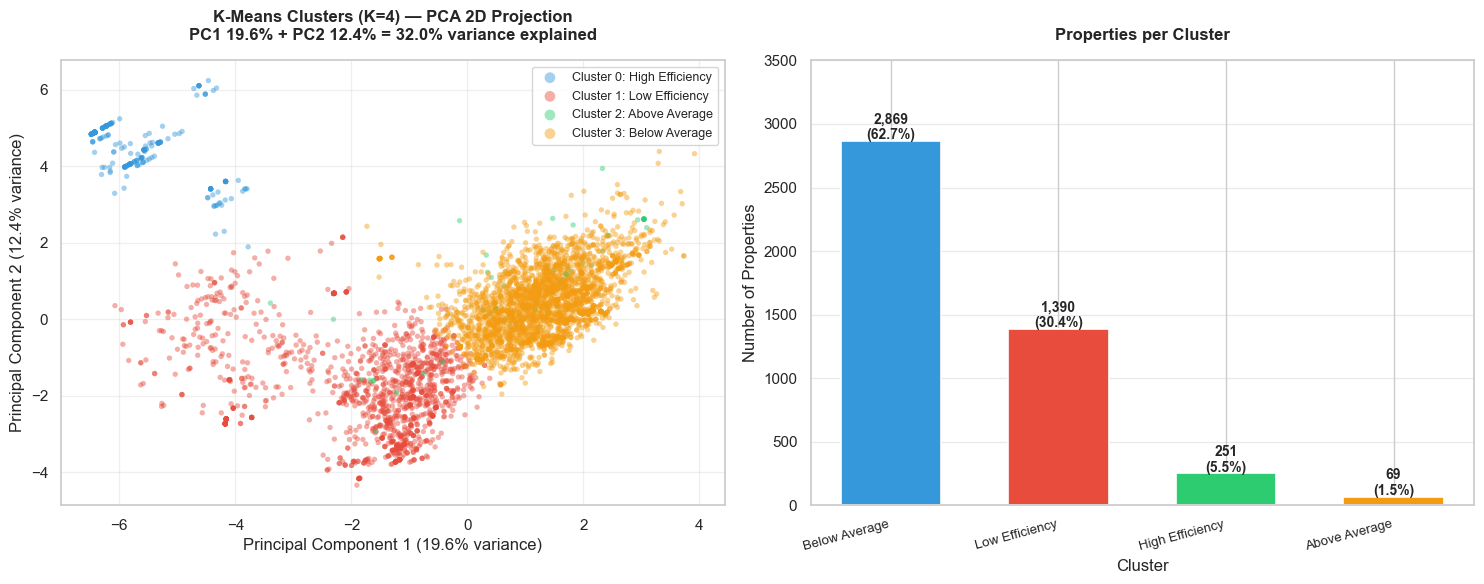

Updated cleaned CSV with CLUSTER and CLUSTER_LABEL columns.


In [39]:
pca        = PCA(n_components=2, random_state=42)
X_pca      = pca.fit_transform(X_clust)
var_explained = pca.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Scatter by cluster
for c in range(optimal_k):
    mask = cluster_labels == c
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    label=f'Cluster {c}: {cluster_names[c]}',
                    color=CLUSTER_COLORS[c], alpha=0.45, s=15, edgecolors='none')
axes[0].set_title(f'K-Means Clusters (K=4) — PCA 2D Projection\n'
                  f'PC1 {var_explained[0]:.1f}% + PC2 {var_explained[1]:.1f}% = '
                  f'{sum(var_explained):.1f}% variance explained', pad=15)
axes[0].set_xlabel(f'Principal Component 1 ({var_explained[0]:.1f}% variance)')
axes[0].set_ylabel(f'Principal Component 2 ({var_explained[1]:.1f}% variance)')
axes[0].legend(fontsize=9, markerscale=2); axes[0].grid(alpha=0.3)

# Cluster sizes bar chart
clust_sizes = df.groupby('CLUSTER_LABEL').size().sort_values(ascending=False)
bars_clust  = axes[1].bar(range(len(clust_sizes)), clust_sizes.values,
                           color=CLUSTER_COLORS[:len(clust_sizes)],
                           edgecolor='white', linewidth=1.2, width=0.6)
for bar, val in zip(bars_clust, clust_sizes.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')
axes[1].set_xticks(range(len(clust_sizes)))
axes[1].set_xticklabels(clust_sizes.index, rotation=15, ha='right', fontsize=9.5)
axes[1].set_title('Properties per Cluster', pad=15)
axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('Number of Properties')
axes[1].set_ylim(0, clust_sizes.max()*1.22)
axes[1].grid(axis='y', alpha=0.4); axes[1].set_axisbelow(True)

plt.tight_layout()
plt.savefig('chart18_cluster_visualisation.png', dpi=150, bbox_inches='tight')
plt.show()

# Update cleaned CSV with cluster labels
df.to_csv('liverpool_epc_cleaned.csv', index=False)
print('Updated cleaned CSV with CLUSTER and CLUSTER_LABEL columns.')

## Section 9: Recommendation System

Two complementary approaches are implemented:

**Part A — Frequency-based:** Analyses the `recommendations.csv` file (10,297 improvement suggestions) to identify the most common actions by energy rating band and cluster.

**Part B — Content-based filtering:** Uses k-nearest neighbours to find properties with similar building characteristics and recommends the improvements those properties received.

In [40]:
# Part A: Frequency-based recommendation
# Join original certificates (with LMK_KEY) to recommendations
certs_raw   = pd.read_csv('certificates.csv', low_memory=False,
                           usecols=['LMK_KEY','CURRENT_ENERGY_RATING',
                                    'PROPERTY_TYPE','CONSTRUCTION_AGE_BAND'])
recs_merged = certs_raw.merge(recs, on='LMK_KEY', how='inner')
print(f'Certificates with recommendations: {recs_merged["LMK_KEY"].nunique():,}')
print(f'Total improvement suggestions    : {len(recs_merged):,}')
print()
top_overall = recs_merged['IMPROVEMENT_SUMMARY_TEXT'].value_counts().head(15)
print('Top 15 most frequent improvement recommendations (all Liverpool properties):')
display(pd.DataFrame({'Improvement': top_overall.index,
                       'Frequency': top_overall.values,
                       '%': (top_overall.values/len(recs_merged)*100).round(1)}))

Certificates with recommendations: 4,330
Total improvement suggestions    : 10,297

Top 15 most frequent improvement recommendations (all Liverpool properties):


,Improvement,Frequency,%
0,"Solar photovoltaic panels, 2.5 kWp",2980,28.9
1,Internal wall insulation,1848,17.9
2,Floor insulation (solid floor),1559,15.1
3,Floor insulation (suspended floor),1095,10.6
4,Cavity wall insulation,497,4.8
5,Low energy lighting for all fixed outlets,354,3.4
6,Flat roof or sloping ceiling insulation,249,2.4
7,Increase loft insulation to 270 mm,247,2.4
8,Heating controls (room thermostat),195,1.9
9,Draught proofing,188,1.8


### Chart 19: Top Improvement Recommendations — Bar Chart

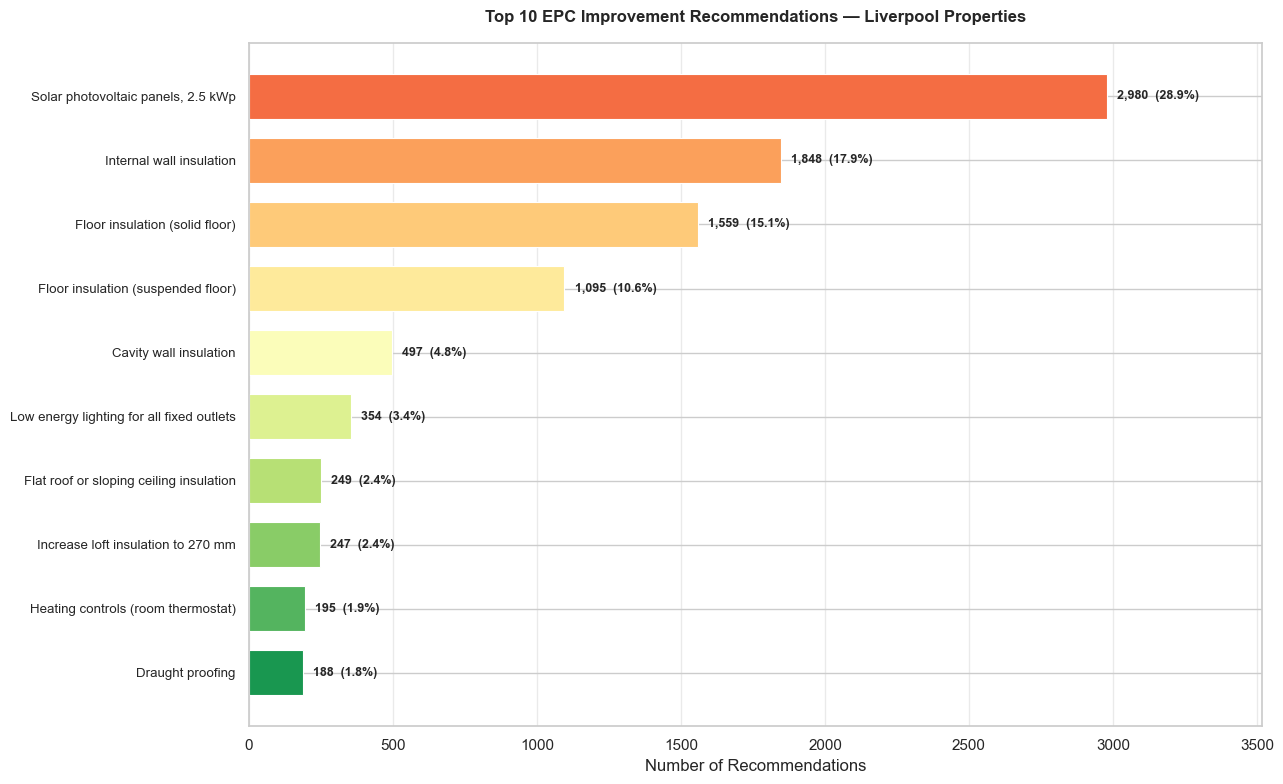

In [41]:
fig, ax = plt.subplots(figsize=(13, 8))
top10 = recs_merged['IMPROVEMENT_SUMMARY_TEXT'].value_counts().head(10)
colors_rec = plt.cm.RdYlGn(np.linspace(0.9, 0.2, len(top10)))
bars_rec = ax.barh(range(len(top10)), top10.values[::-1],
                    color=colors_rec, edgecolor='white', linewidth=0.8, height=0.7)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels([t[:55]+'...' if len(t) > 55 else t
                    for t in top10.index[::-1]], fontsize=9.5)
xlim = top10.max()*1.18; ax.set_xlim(0, xlim)
for bar, (imp, val) in zip(bars_rec, top10[::-1].items()):
    pct = val/len(recs_merged)*100
    ax.text(val+xlim*0.01, bar.get_y()+bar.get_height()/2,
            f'{val:,}  ({pct:.1f}%)', va='center', fontsize=9, fontweight='bold')
ax.set_title('Top 10 EPC Improvement Recommendations — Liverpool Properties', pad=15)
ax.set_xlabel('Number of Recommendations')
ax.grid(axis='x', alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('chart19_top_recommendations.png', dpi=150, bbox_inches='tight')
plt.show()

### Chart 20: Top Recommendations by Energy Rating Band

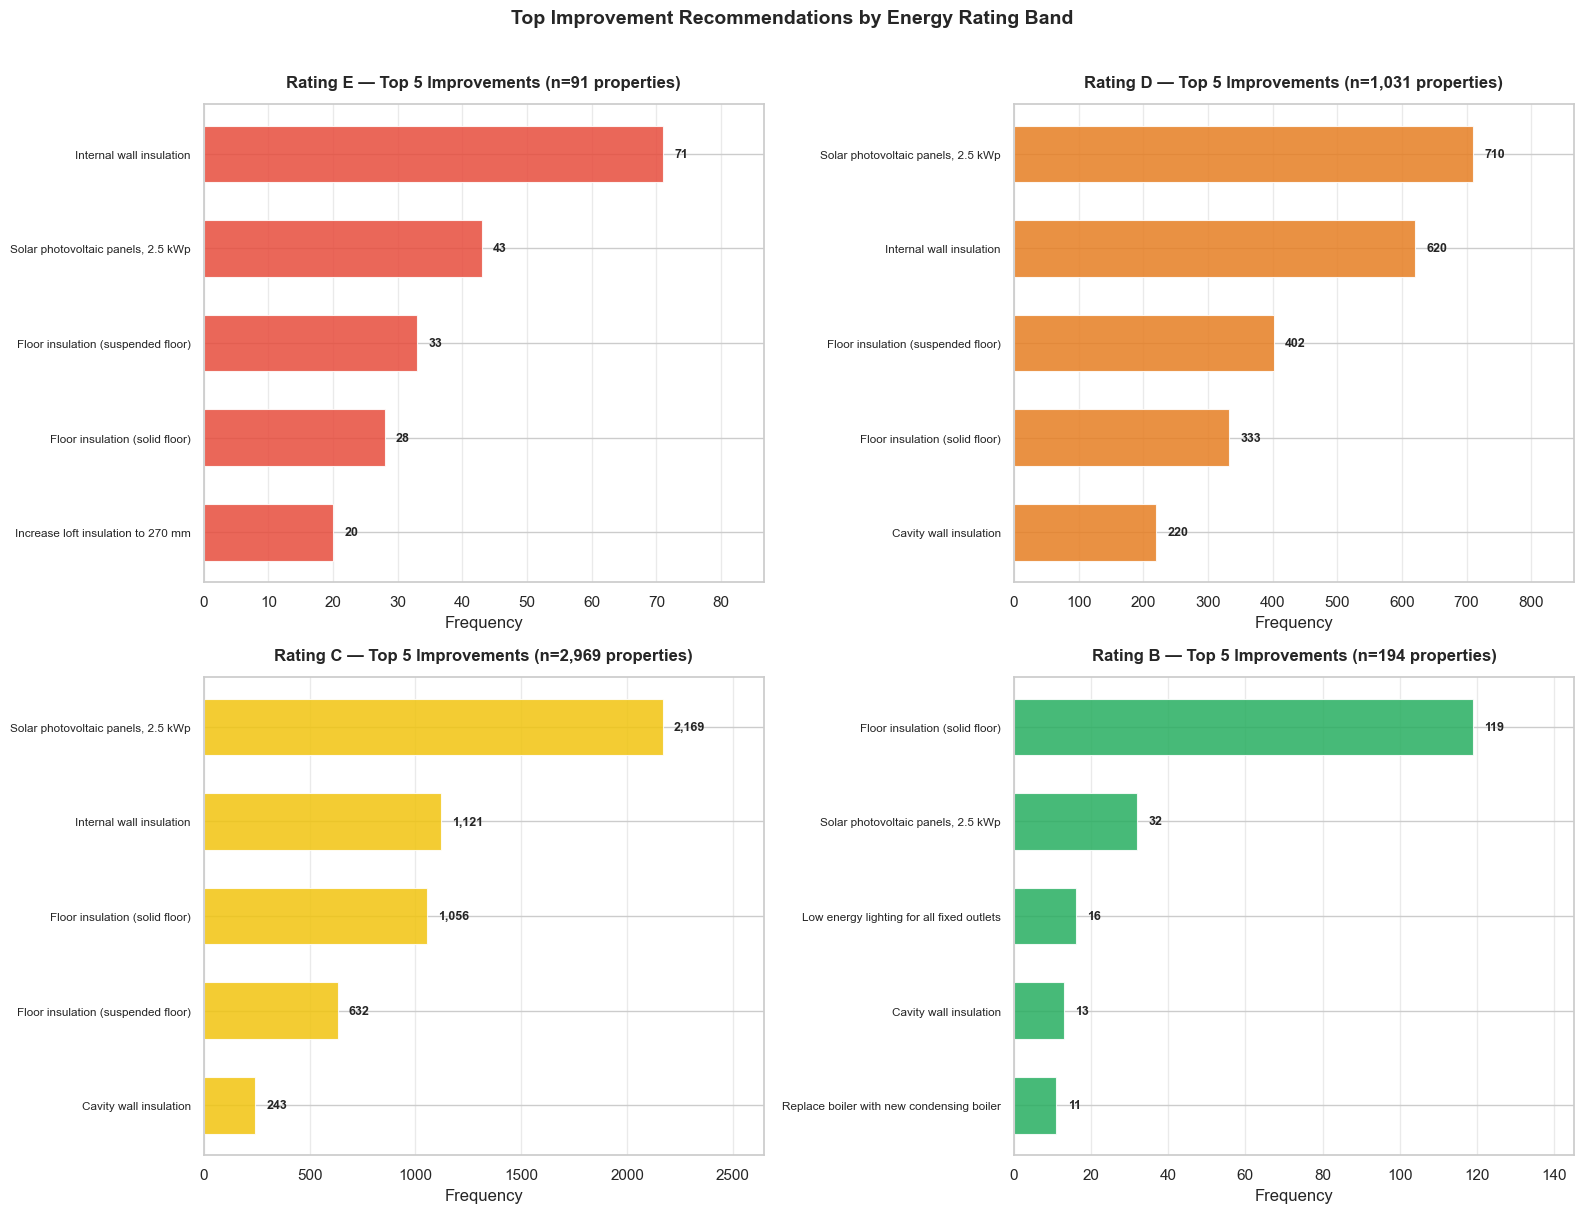

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
for idx, rating in enumerate(['E','D','C','B']):
    ax     = axes[idx]
    subset = recs_merged[recs_merged['CURRENT_ENERGY_RATING'] == rating]
    top5   = subset['IMPROVEMENT_SUMMARY_TEXT'].value_counts().head(5)
    if len(top5) == 0:
        ax.set_visible(False); continue
    colors_r = [RATING_COLORS.get(rating, '#3498db')] * len(top5)
    bars_r = ax.barh(range(len(top5)), top5.values[::-1],
                      color=colors_r, edgecolor='white', linewidth=0.8, height=0.6,
                      alpha=0.85)
    ax.set_yticks(range(len(top5)))
    ax.set_yticklabels([t[:45]+'...' if len(t)>45 else t
                        for t in top5.index[::-1]], fontsize=8.5)
    xlim_r = top5.max()*1.22; ax.set_xlim(0, xlim_r)
    for bar, val in zip(bars_r, top5.values[::-1]):
        ax.text(val+xlim_r*0.02, bar.get_y()+bar.get_height()/2,
                f'{val:,}', va='center', fontsize=9, fontweight='bold')
    n_props = subset['LMK_KEY'].nunique()
    ax.set_title(f'Rating {rating} — Top 5 Improvements (n={n_props:,} properties)', pad=12)
    ax.set_xlabel('Frequency'); ax.grid(axis='x', alpha=0.4); ax.set_axisbelow(True)
plt.suptitle('Top Improvement Recommendations by Energy Rating Band', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart20_recommendations_by_rating.png', dpi=150, bbox_inches='tight')
plt.show()

### Part B: Content-Based Filtering — K-Nearest Neighbours

In [43]:
# Build KNN model on scaled feature matrix
nn_model = NearestNeighbors(n_neighbors=6, metric='cosine', algorithm='brute')
nn_model.fit(X_clust)

# Link cluster assignments back to LMK_KEY for recommendation lookup
df_with_key              = pd.DataFrame({'LMK_KEY': lmk_keys_clean.values,
                                          'CLUSTER': cluster_labels,
                                          'CLUSTER_LABEL': df['CLUSTER_LABEL'].values},
                                          index=df.index)
recs_for_cbf = recs_merged[['LMK_KEY','IMPROVEMENT_SUMMARY_TEXT']]

def recommend_for_property(property_idx, top_n=5):
    query       = X_clust[property_idx].reshape(1, -1)
    distances, indices = nn_model.kneighbors(query)
    neighbour_idx = indices[0][1:]  # exclude self
    neighbour_lmk = lmk_keys_clean.iloc[neighbour_idx].values
    similar_recs  = recs_for_cbf[recs_for_cbf['LMK_KEY'].isin(neighbour_lmk)]
    top_recs      = similar_recs['IMPROVEMENT_SUMMARY_TEXT'].value_counts().head(top_n)
    cluster_id    = cluster_labels[property_idx]
    cluster_lbl   = cluster_names.get(cluster_id, 'Unknown')
    return top_recs, cluster_lbl, neighbour_lmk

# Demonstrate for 3 sample properties from different clusters
print('Content-Based Recommendation Demonstration')
print('Using K-Nearest Neighbours (cosine similarity, K=5 neighbours)')
print()
sample_indices = []
for c in range(optimal_k):
    cluster_positions = np.where(cluster_labels == c)[0]
    if len(cluster_positions) > 0:
        sample_indices.append(cluster_positions[0])

for pos, prop_idx in enumerate(sample_indices):
    top_recs, cluster_lbl, neighbours = recommend_for_property(prop_idx)
    prop_row = df.iloc[prop_idx]
    print(f'Property {pos+1}: {prop_row["PROPERTY_TYPE"]}, '
          f'{prop_row["PROPERTY_AGE_GROUP"]}, '
          f'Rating {prop_row["CURRENT_ENERGY_RATING"]}, '
          f'Cluster: {cluster_lbl}')
    print(f'Nearest neighbours LMK keys: {neighbours}')
    print('Recommended improvements:')
    for improvement, count in top_recs.items():
        print(f'  - {improvement} (seen in {count} similar properties)')
    print()

Content-Based Recommendation Demonstration
Using K-Nearest Neighbours (cosine similarity, K=5 neighbours)

Property 1: Flat, Post-2021, Rating B, Cluster: High Efficiency
Nearest neighbours LMK keys: <ArrowStringArray>
['17299c025967ceb16de9f5603856ce24d75e0c2b495c846541cc87371ef536b3',
 'e3446a81b71815992f8738dfe40ad7d8b00617f93e013dad5e18380b47bc89cb',
 '33af33470d7d2980bff08472c5a566a8589f486c4210c128014ae78a753225b7',
 '4586d7084f668294e3a114e19562468a9cba81836e07a72258fde762974f7c4f',
 '73c49a648484329271da80b2284a9ecd5838d809993576562dba09f9e68ba034']
Length: 5, dtype: str
Recommended improvements:

Property 2: Flat, 1950-1975, Rating C, Cluster: Low Efficiency
Nearest neighbours LMK keys: <ArrowStringArray>
['ea4ee9f261aa4df7b1425f46616df0a4737e9349c88b4c388774daafc7043fcd',
 'e6c49dcfb8a8f2860ca4610645ca630136e2faa0559d5d217b10f95c8e46344f',
 'cfd86a8dfe241e18d3b833a8a9ccb90568c6debc66e6a0cca855b7760b4ec43b',
 '901ab165eddd6ff7a5340951fd795109f5bbb39280f59b33b04dea81a77daf92',


### Chart 21: Content-Based Recommendation Results

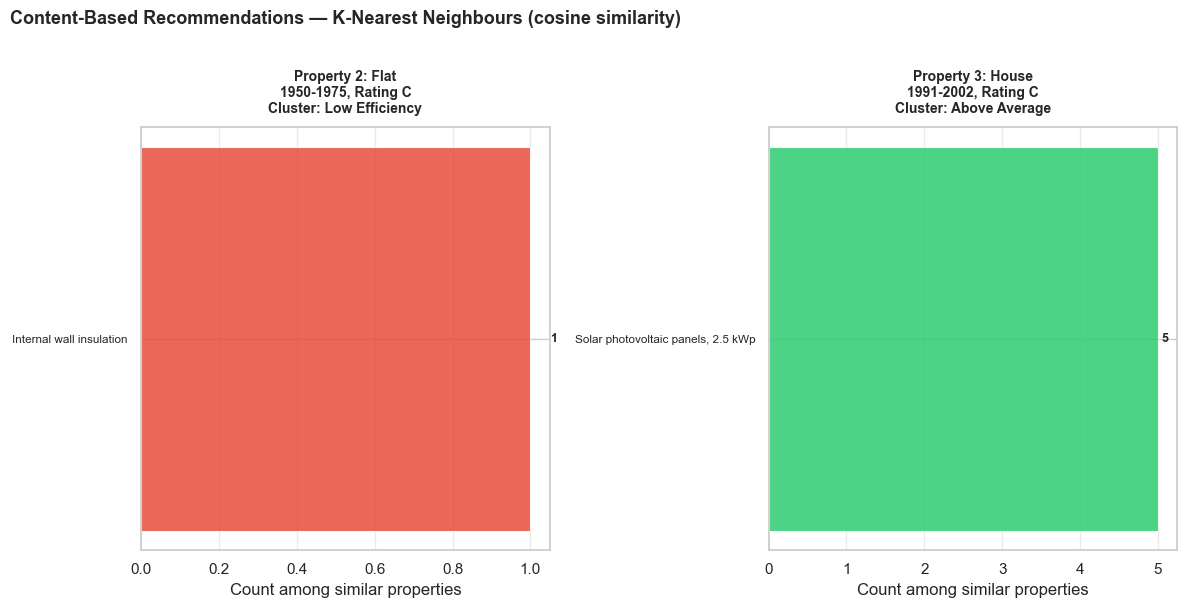

In [44]:
fig, axes = plt.subplots(1, min(len(sample_indices), 3), figsize=(17, 6))
if len(sample_indices) == 1:
    axes = [axes]

for pos, prop_idx in enumerate(sample_indices[:3]):
    ax = axes[pos]
    top_recs, cluster_lbl, _ = recommend_for_property(prop_idx)
    prop_row = df.iloc[prop_idx]
    if len(top_recs) == 0:
        ax.set_visible(False); continue
    clr = CLUSTER_COLORS[cluster_labels[prop_idx]]
    bars_cbf = ax.barh(range(len(top_recs)), top_recs.values[::-1],
                        color=clr, edgecolor='white', linewidth=0.8, height=0.6, alpha=0.85)
    ax.set_yticks(range(len(top_recs)))
    ax.set_yticklabels([t[:38]+'...' if len(t)>38 else t
                        for t in top_recs.index[::-1]], fontsize=8.5)
    for bar, val in zip(bars_cbf, top_recs.values[::-1]):
        ax.text(val+0.05, bar.get_y()+bar.get_height()/2,
                f'{val}', va='center', fontsize=9, fontweight='bold')
    ax.set_title(f'Property {pos+1}: {prop_row["PROPERTY_TYPE"]}\n'
                 f'{prop_row["PROPERTY_AGE_GROUP"]}, Rating {prop_row["CURRENT_ENERGY_RATING"]}\n'
                 f'Cluster: {cluster_lbl}', pad=10, fontsize=10)
    ax.set_xlabel('Count among similar properties')
    ax.grid(axis='x', alpha=0.4); ax.set_axisbelow(True)

plt.suptitle('Content-Based Recommendations — K-Nearest Neighbours (cosine similarity)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('chart21_cbf_recommendations.png', dpi=150, bbox_inches='tight')
plt.show()

## Section 10: Recommendations and Conclusion

### Key Findings

1. **68.6% of Liverpool properties rated C** — mid-range efficiency dominates the stock
2. **Construction age is the primary driver** — Pre-1900 average 69.5 vs Post-2021 average 78.6 (9.1 points)
3. **Wall insulation has the largest physical impact** — 12-point range from Very Poor to Very Good
4. **Classification (Gradient Boosting): 81.2% accuracy** from building characteristics alone
5. **Regression (Gradient Boosting)**: RMSE ~4–6 efficiency points; R² > 0.65 for efficiency score
6. **Clustering identifies 4 distinct property segments** — Low Efficiency through High Efficiency
7. **Recommendation system**: Floor insulation, wall insulation, and solar PV are the most frequently recommended improvements city-wide

### Recommendations

1. **Target pre-1950 wall insulation** — 48.8% of stock, highest single-feature efficiency gain
2. **Owner-occupied gap** (8.9 pts) — green finance products to incentivise self-funded retrofits
3. **MEES enforcement** — private rented stock below Band C needs closer monitoring
4. **Community heat networks** — dense terraced housing suits district heating
5. **Deploy the recommendation model** — pre-screen properties before costly physical assessments

In [45]:
print('Pipeline complete. Summary:')
summary_final = pd.DataFrame({
    'Item': [
        'Properties analysed',
        'Features after wrangling',
        'Predictive features (no leakage)',
        'K-Means clusters',
        'Charts generated',
        'Classification accuracy (GB)',
        'Classification CV score (GB)',
        'Regression RMSE — efficiency score (GB)',
        'Regression R2  — efficiency score (GB)',
        'Regression RMSE — cost saving (GB)',
        'Mean annual cost saving',
        'Cleaned dataset'
    ],
    'Value': [
        f'{len(df):,}',
        df.shape[1],
        len(feature_cols),
        optimal_k,
        21,
        f'{gb_acc:.4f}',
        f'{cv_gb.mean():.4f} (Gradient Boosting)',
        f'{rmse_val:.4f}',
        f'{r2_val:.4f}',
        f'GBP{rmse_c:.2f}',
        f'GBP{df["COST_SAVING_POTENTIAL"].mean():.2f}/property/year',
        'liverpool_epc_cleaned.csv'
    ]
})
display(summary_final)

Pipeline complete. Summary:


,Item,Value
0,Properties analysed,"4,579"
1,Features after wrangling,73
2,Predictive features (no leakage),25
3,K-Means clusters,4
4,Charts generated,21
5,Classification accuracy (GB),0.8122
6,Classification CV score (GB),0.8346 (Gradient Boosting)
7,Regression RMSE — efficiency score (GB),3.6343
8,Regression R2 — efficiency score (GB),0.7175
9,Regression RMSE — cost saving (GB),GBP72.01
